In [2]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [3]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp)
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
print(df_all.head())
print(df_all_sorted.head())





astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0
    TIME_NS  TIME_S  TIME_ABS  EVENT   MCRUN  TEL_ID  \
0  15104575       0  15104575   2217  263211       1   
1  25307129       0  25307129   7009  263211       1   
2  28859186       0  28859186   2217  263212       1   
3  32680807       0  32680807   4213  263212       1   
4  35023796       0  35023796    417  263213       1   

                                                  HG  \
0  [[2158, 2264, 2118, 2251, 2150, 2144, 2247, 22...   
1  [[2251, 2145, 2137, 2122, 2236, 2138, 2146, 22...   
2  [[2107, 2316, 2213, 2026, 2181, 2110, 2212, 21...

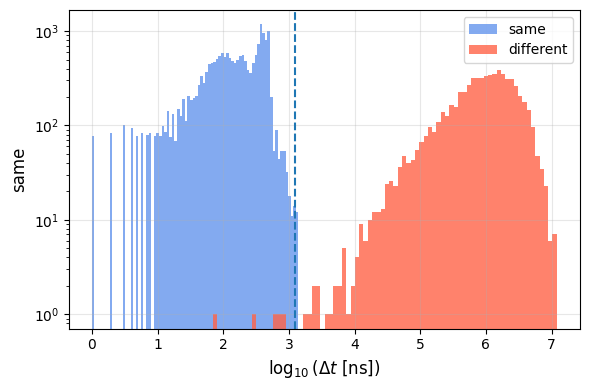

Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'HG', 'LG',
       'TTP', 'shape'],
      dtype='object')

In [4]:
delta_t=np.diff(df_all_sorted["TIME_ABS"])
delta_ts = delta_t[delta_t > 0] #uso maschere e cambio

#ordino eventi con il for e suddivisione same e different
df_all_sorted=df_all_sorted.sort_values(["MCRUN","EVENT","TIME_ABS"]).reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()

delta_t_same = []
delta_t_diff = []

for i in range(1, len(df_all_sorted)):
    if ((df_all_sorted.loc[i, "MCRUN"]==df_all_sorted.loc[i-1, "MCRUN"])&
        (df_all_sorted.loc[i, "EVENT"] ==df_all_sorted.loc[i-1, "EVENT"])):
        delta_t_same.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
    else:
        delta_t_diff.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
delta_t_same = np.array(delta_t_same)
delta_t_diff = np.array(delta_t_diff)
delta_t_same_safe = np.where(delta_t_same > 0, delta_t_same, 1)
delta_t_diff_safe = np.where(delta_t_diff > 0, delta_t_diff, 1)
#suddivido tra stesso evento e evento separato sostituendo i deltat con 1
plt.figure(figsize=(6, 4))
plt.hist(np.log10(delta_t_same[delta_t_same > 0]), bins=80, color='cornflowerblue',
         alpha=0.8,label='same')
plt.hist(np.log10(delta_t_diff[delta_t_diff > 0]), bins=80, color='tomato',
         alpha=0.8,label='different')
plt.yscale('log')
plt.xlabel(r'$\log_{10}(\Delta t\ \mathrm{[ns]})$', fontsize=12)
plt.ylabel('same', fontsize=12)
#plt.xlim(left=0)
plt.tight_layout()
plt.grid(alpha=0.3)
plt.legend()
plt.axvline(3.1, linestyle='--')
plt.show()
df_all_sorted.columns


In [5]:
dt = np.diff(df_all_sorted["TIME_ABS"].values)
logdt = np.log10(np.where(dt > 0, dt, 1e-12))

mask = logdt < 3  

df_target = df_all_sorted.iloc[1:][mask]

print(df_target[["TIME_NS", "TIME_S","TIME_ABS"]])

         TIME_NS  TIME_S    TIME_ABS
5        3679036       0     3679036
6        3679123       0     3679123
7        3679447       0     3679447
8        3679515       0     3679515
9        3679547       0     3679547
...          ...     ...         ...
25385  329474698       9  9329474698
25389  332544989       9  9332544989
25392  336171983       9  9336171983
25393  336172168       9  9336172168
25394  336173029       9  9336173029

[18864 rows x 3 columns]


In [6]:
# assicuriamoci che sia ordinato
df = df_all_sorted.sort_values("TIME_ABS").reset_index(drop=True)

# differenze temporali tra eventi consecutivi
df["dt"] = df["TIME_ABS"].diff()

# nuova finestra se il gap supera 1000 ns
new_group = (np.log10(df["dt"]) >= 3.1) | df["dt"].isna()# da true=1 o false=0
df["time_group"] = new_group.cumsum()  #cumsum=somma comulativa= mi somma cumulativamente
#Conta quante volte è iniziato un nuovo gruppo fino a questo punto
df=df[(df["shape"]>5.16e6 )]
# id finestra 
print(df[["TIME_NS", "TIME_S","TIME_ABS","dt", "time_group","shape"]])


         TIME_NS  TIME_S    TIME_ABS         dt  time_group    shape
61      35023969       0    35023969      173.0          24  5160174
113     54610671       0    54610671  2610774.0          38  5193069
114     54610859       0    54610859      188.0          38  5188157
115     54611007       0    54611007      148.0          38  5195257
116     54611100       0    54611100       93.0          38  5191542
...          ...     ...         ...        ...         ...      ...
25330  307305197       9  9307305197      331.0        6493  5189303
25331  307305247       9  9307305247       50.0        6493  5211232
25332  307305261       9  9307305261       14.0        6493  5212289
25333  307305696       9  9307305696      435.0        6493  5188818
25334  307305719       9  9307305719       23.0        6493  5194849

[4224 rows x 6 columns]


/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
good_groups = df.groupby("time_group").size()[df.groupby("time_group").size() >= 3].index
len(good_groups)

596

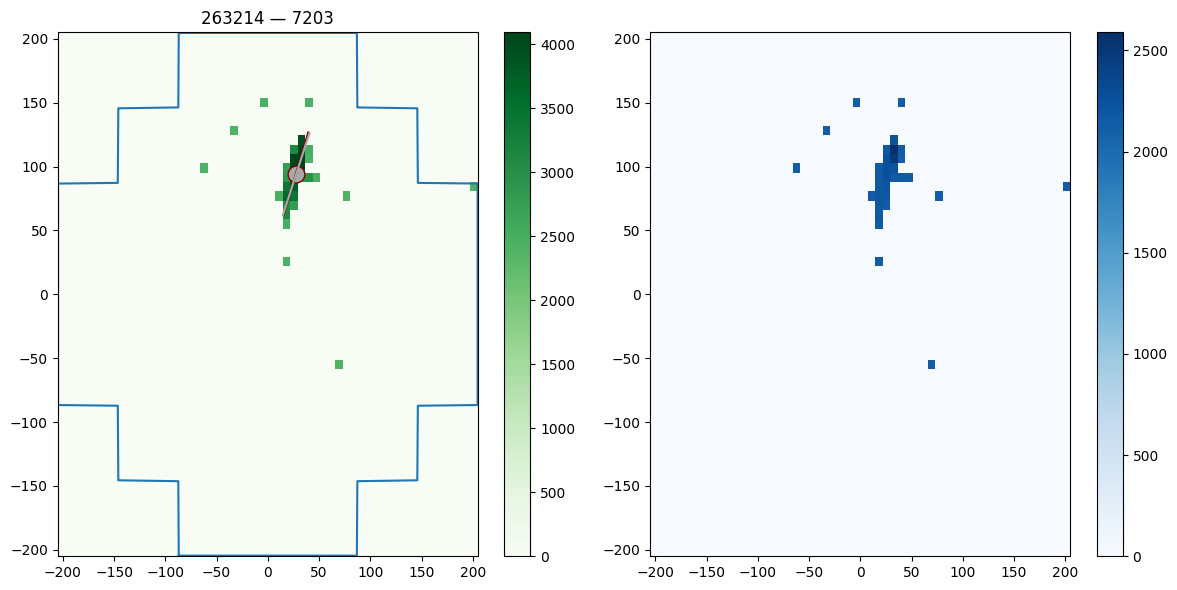

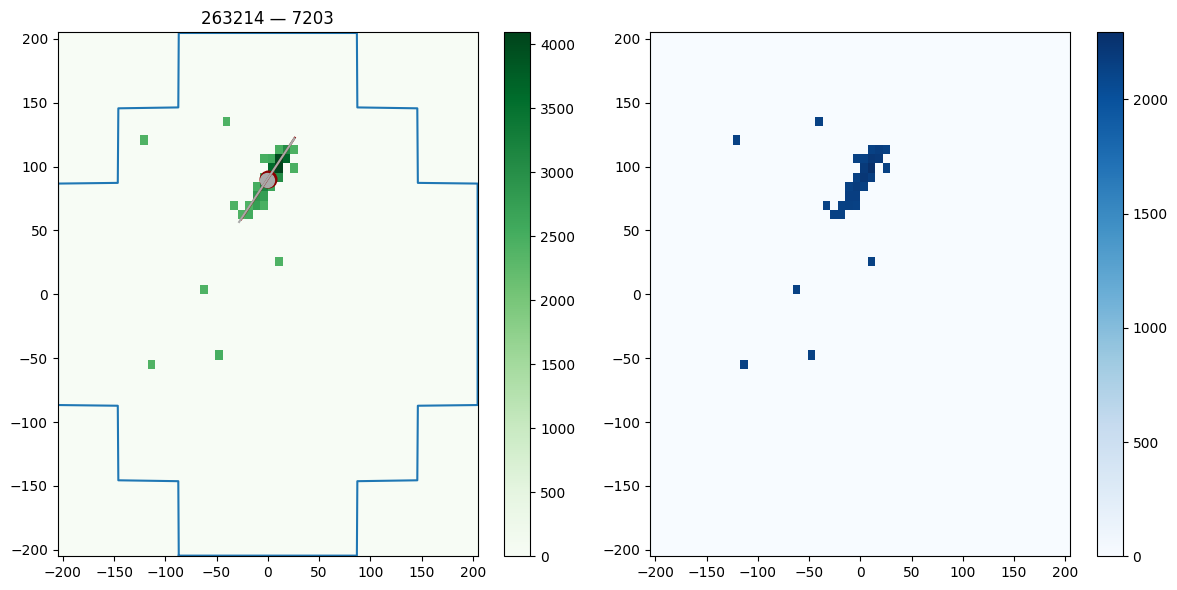

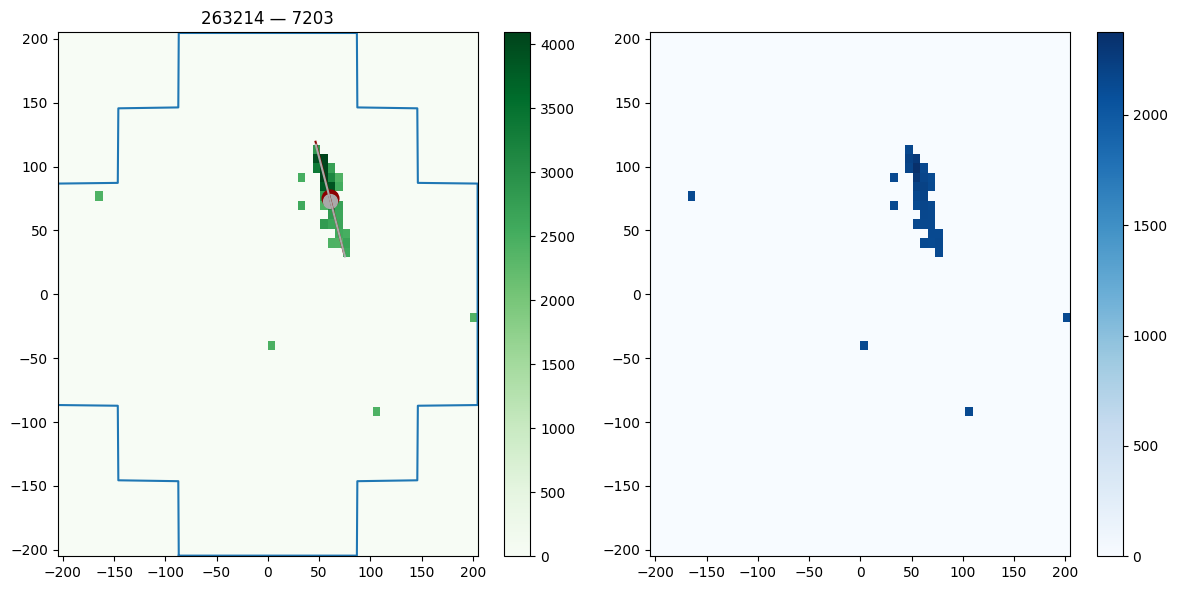

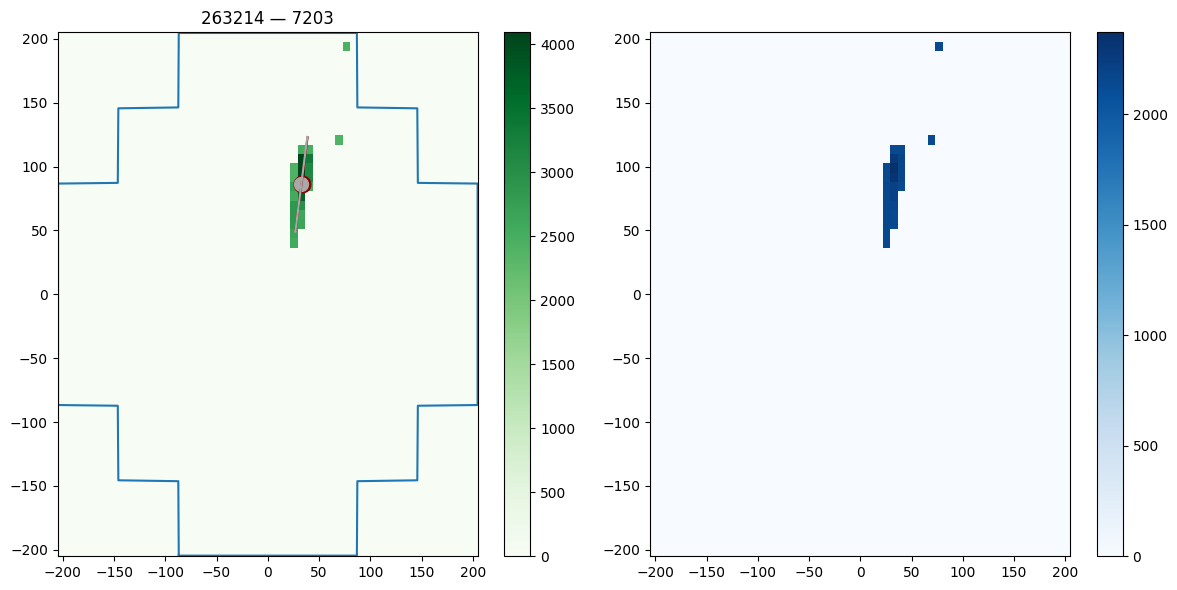

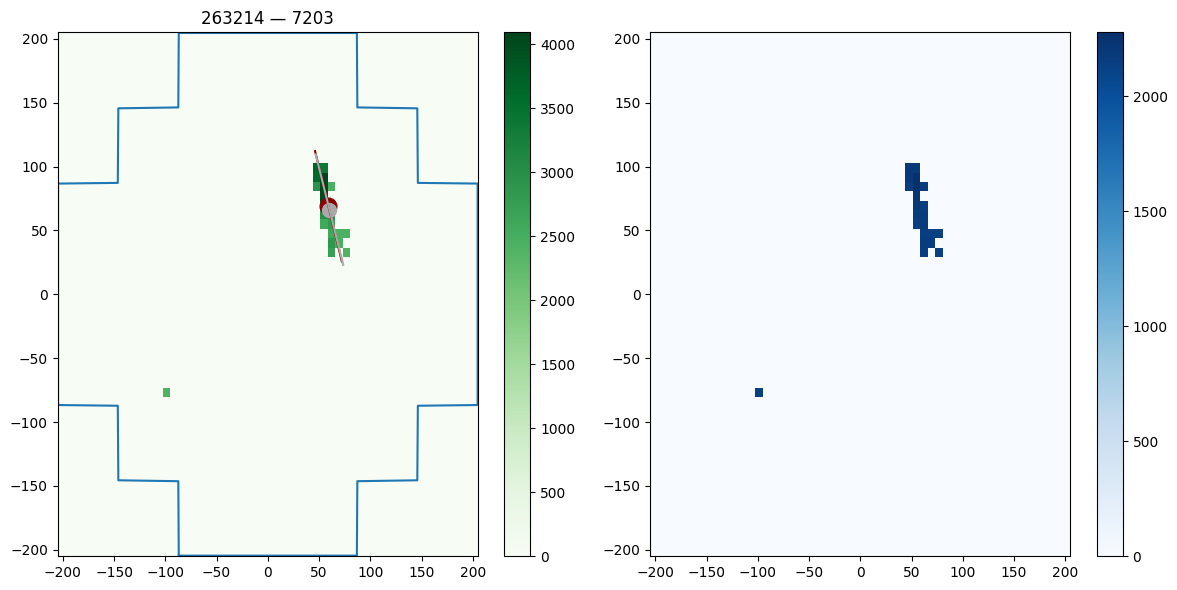

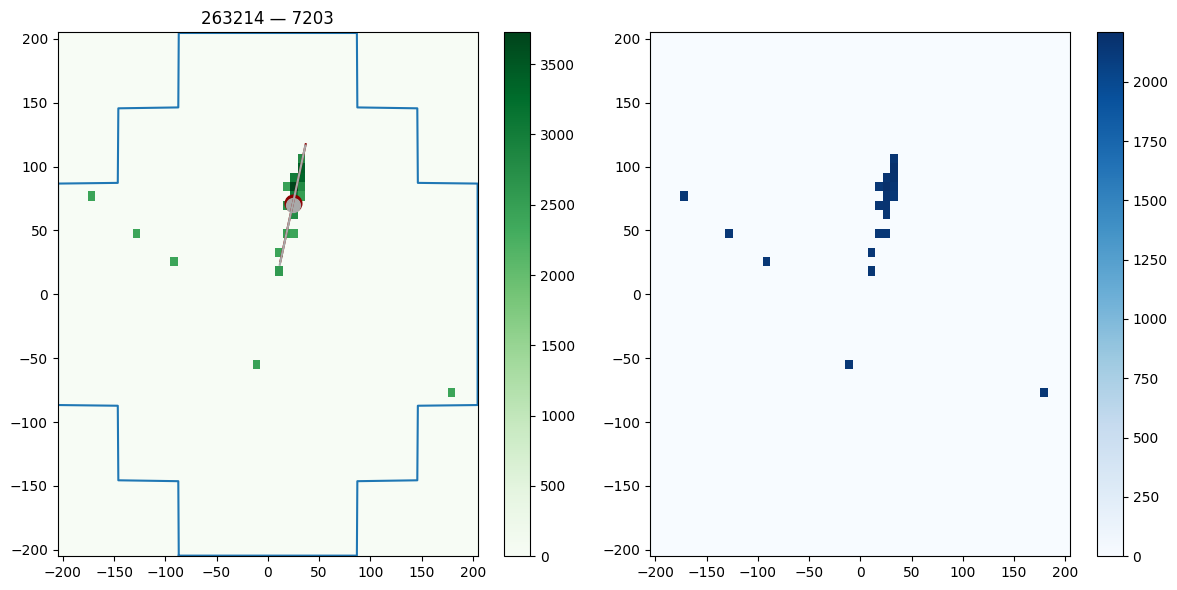

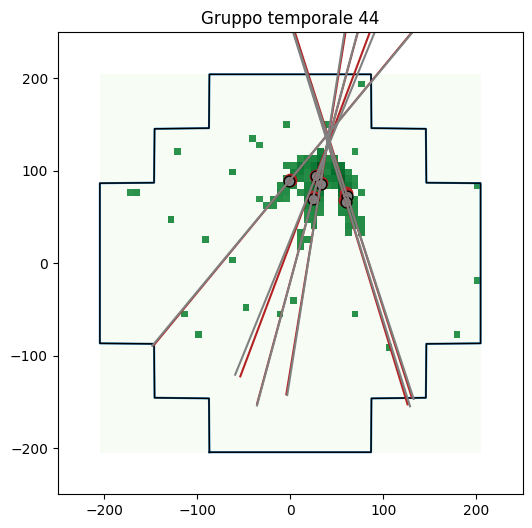

In [8]:

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)
rette_hg = []
rette_lg = []
for gid in good_groups[1:2]:
    weights = np.zeros_like(np.array(df['HG'])[0])
    mask_tot = np.zeros((37, 64), dtype=bool)
    df_target = df[df["time_group"] == gid].reset_index(drop=True)
    for iv in range(len(df_target)):

        hgev = np.array(df_target['HG'])[iv]
        weights += hgev  # somma elemento per elemento
        lgev = np.array(df_target['LG'])[iv]
        ttpev = np.array(df_target['TTP'])[iv]
        # filtro temporale
        pxmask =(hgev>2400) & (ttpev < 255)
        mask_tot |= pxmask      # somma logica (OR)
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0= np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # --------------------------

        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

        # ---------- direzione ellisse ----------
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0]-cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0]-cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)

        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])

        # ---------- salvo le rette ----------
        rette_hg.append({
            "p0": np.array([meanx_hg, meany_hg]),
            "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
            "tel": df_target["TEL_ID"][iv]
        })

        rette_lg.append({
            "p0": np.array([meanx_lg, meany_lg]),
            "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
            "tel": df_target["TEL_ID"][iv]
        })
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)            
        hl = ax[0].hist2d(x_pix[pxmask].flatten(),y_pix[pxmask].flatten(),
                          weights=hgev[pxmask].flatten(),range=((-205, 205), (-205, 205)),
                          bins=7*8, cmap='Greens')
        hh = ax[1].hist2d(x_pix[pxmask].flatten(),y_pix[pxmask].flatten(),
                          weights=lgev[pxmask].flatten(),range=((-205, 205), (-205, 205)),
                          bins=7*8, cmap='Blues')
        fig.colorbar(hl[3], ax=ax[0])
        fig.colorbar(hh[3], ax=ax[1])
        for ai in ax:
            ai.plot(xfp, yfp)
            ai.set_title(f"{df_target['MCRUN'][iv]} — {df_target['EVENT'][iv]}")
            #centroidi
            ai.plot(meanx_hg, meany_hg, 'o',markersize=12, color='darkred')
            ai.plot(meanx_lg, meany_lg, 'o',markersize=10, color='darkgrey')
            #le rette_hg
            ai.plot( [meanx_hg-2*np.sqrt(l1_hg)*np.cos(theta_hg),
                      meanx_hg+2*np.sqrt(l1_hg)*np.cos(theta_hg)],
                      [meany_hg-2*np.sqrt(l1_hg)*np.sin(theta_hg),meany_hg+
                       2*np.sqrt(l1_hg)*np.sin(theta_hg)],'-',color='darkred')
            ai.plot( [meanx_lg-2*np.sqrt(l1_lg)*np.cos(theta_lg),
                        meanx_lg+2*np.sqrt(l1_lg)*np.cos(theta_lg)],
                        [meany_lg-2*np.sqrt(l1_lg)*np.sin(theta_lg),
                        meany_lg+2*np.sqrt(l1_lg)*np.sin(theta_lg)],
                        '-', color='darkgrey')
            plt.show()
    plt.show()
weights=np.array(weights)
fig, ax = plt.subplots(figsize=(6,6))

ax.hist2d(x_pix[mask_tot].flatten(),y_pix[mask_tot].flatten(),
                          weights=weights[mask_tot].flatten(),range=((-205, 205), (-205, 205)),
                          bins=7*8, cmap='Greens')
ax.set_title(f"Gruppo temporale {gid}")
ax.plot(xfp, yfp)
ax.plot(xfp, yfp, 'k-', linewidth=1)

xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
L = 0.4 * np.sqrt((xmax-xmin)**2 + (ymax-ymin)**2)

for r in rette_hg:
    p0, d = r["p0"], r["d"]
    ax.scatter(*p0, s=80, color="firebrick")
    ax.plot([p0[0]-L*d[0], p0[0]+L*d[0]],
            [p0[1]-L*d[1], p0[1]+L*d[1]],
            color="firebrick")

for r in rette_lg:
    p0, d = r["p0"], r["d"]
    ax.scatter(*p0, s=60, color="grey", edgecolor="black")
    ax.plot([p0[0]-L*d[0], p0[0]+L*d[0]],
            [p0[1]-L*d[1], p0[1]+L*d[1]],
            color="grey")

ax.set_xlim(-250,250)
ax.set_ylim(-250,250)

plt.show()



 gruppo 38 con 9 eventi


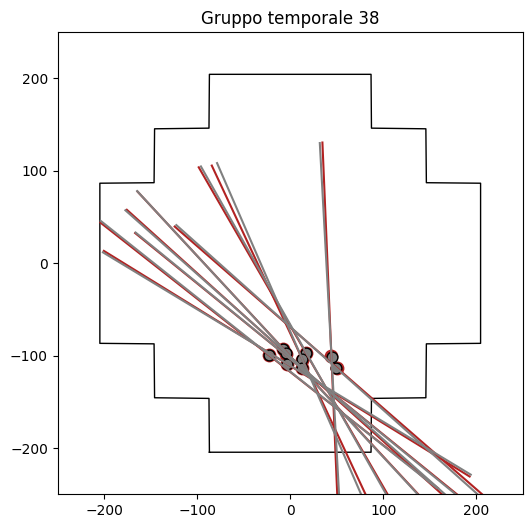


 gruppo 44 con 6 eventi


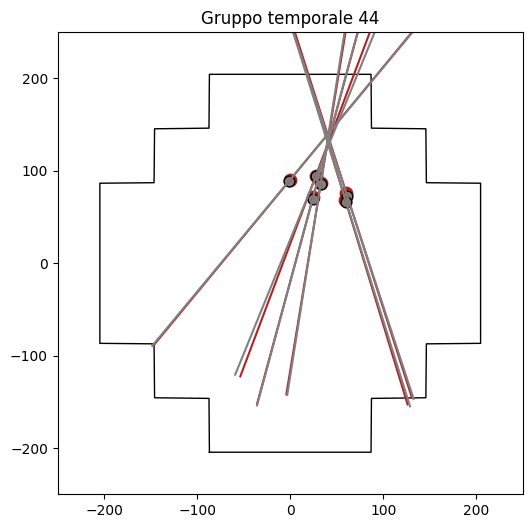

In [18]:
for gid in good_groups[:2]:

    df_target = df[df["time_group"] == gid].reset_index(drop=True)

    print(f"\n gruppo {gid} con {len(df_target)} eventi")

    xfp, yfp = at.utils.camera.get_xy_footprint()
    y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T

    x_pix = at.reshape(x_pix)
    y_pix = at.reshape(y_pix)

    rette_hg = []
    rette_lg = []

    for iv in range(len(df_target)):
        
        itel = df_target["TEL_ID"].iloc[iv]
        hgev = np.array(df_target['HG'])[iv]
        lgev = np.array(df_target['LG'])[iv]
        ttpev = np.array(df_target['TTP'])[iv]

        pxmask = (hgev > 2400) & (ttpev < 255)

        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)
        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]

        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)
        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

        l1_hg = (cov_hg[0,0]+cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0]-cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        l1_lg = (cov_lg[0,0]+cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0]-cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)

        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])

        rette_hg.append({"p0": np.array([meanx_hg, meany_hg]), "d": np.array([np.cos(theta_hg), np.sin(theta_hg)]), "tel": itel})
        rette_lg.append({"p0": np.array([meanx_lg, meany_lg]), "d": np.array([np.cos(theta_lg), np.sin(theta_lg)]), "tel": itel})
    
    # ----  ----
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(xfp, yfp, 'k-', linewidth=1)

    xmin, xmax = np.min(xfp), np.max(xfp)
    ymin, ymax = np.min(yfp), np.max(yfp)
    L = 0.4 * np.sqrt((xmax-xmin)**2 + (ymax-ymin)**2)

    for r in rette_hg:
        p0, d = r["p0"], r["d"]
        ax.scatter(*p0, s=80, color="firebrick")
        ax.plot([p0[0]-L*d[0], p0[0]+L*d[0]],
                [p0[1]-L*d[1], p0[1]+L*d[1]],
                color="firebrick")

    for r in rette_lg:
        p0, d = r["p0"], r["d"]
        ax.scatter(*p0, s=60, color="grey", edgecolor="black")
        ax.plot([p0[0]-L*d[0], p0[0]+L*d[0]],
                [p0[1]-L*d[1], p0[1]+L*d[1]],
                color="grey")

    ax.set_title(f"Gruppo temporale {gid}")
    ax.set_xlim(-250,250)
    ax.set_ylim(-250,250)
    plt.show()


In [19]:
def intersection(p1, d1, p2, d2):
    """
    p1, p2 = centroidi
    d1, d2 = direzioni 
    """
    A = np.array([d1, -d2]).T
    b = p2 - p1

    # determinante per capire se sono parallele
    det = np.linalg.det(A)
    if abs(det) < 1e-6:
        return None  
    # risolvi i parametri t
    t = np.linalg.solve(A, b)[0]

    # punto di intersezione
    return p1 + t * d1
# ####################################################
# INTERSEZIONI TRA TUTTE LE COPPIE DI RETTE HG
# ####################################################
N = len(rette_hg)
inters_hg = []

for i in range(N):
    p1 = rette_hg[i]["p0"]
    d1 = rette_hg[i]["d"]
    for j in range(i+1, N):
        p2 = rette_hg[j]["p0"]
        d2 = rette_hg[j]["d"]
        P = intersection(p1, d1, p2, d2)
        if P is not None:
            inters_hg.append(P)

inters_hg = np.array(inters_hg)
v_hg_nf = inters_hg.copy()   


# #####################################################
# INTERSEZIONI TRA TUTTE LE COPPIE DI RETTE LG
# ####################################################à
N = len(rette_lg)
inters_lg = []

for i in range(N):
    p1 = rette_lg[i]["p0"]
    d1 = rette_lg[i]["d"]
    for j in range(i+1, N):
        p2 = rette_lg[j]["p0"]
        d2 = rette_lg[j]["d"]
        P = intersection(p1, d1, p2, d2)
        if P is not None:
            inters_lg.append(P)

inters_lg = np.array(inters_lg)
v_lg_nf = inters_lg.copy()  
#####Filtro i punti troppo lontani (grezzo)###############################################
v_hg= np.array([p for p in v_hg_nf if  all(-1000 <= coord <= 1000 for coord in p)])
v_lg= np.array([p for p in v_lg_nf if  all(-1000 <= coord <= 1000 for coord in p)])



/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


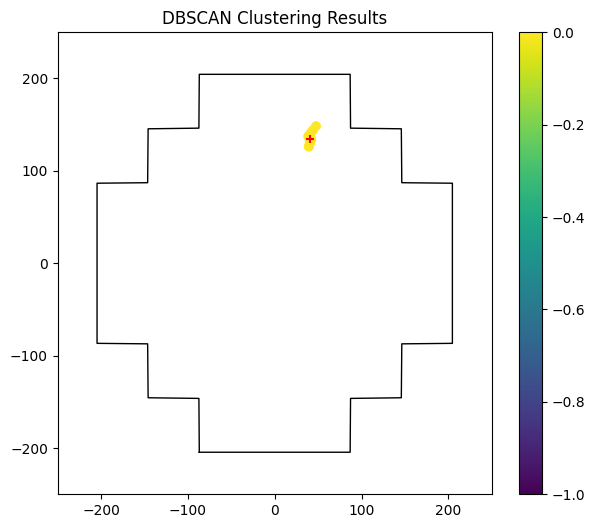

In [20]:
# Perform DBSCAN clustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


epsilon = 20  # Chosen based on k-distance graph
min_samples = 6  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(v_hg)
#suddivido i punti in base al cluster
cluster0 = v_hg[clusters == 0]
cluster1 = v_hg[clusters == 1]
#mi calcolo la mediana dei punti del cluster 0 o 1
centro0 =np.median(cluster0,axis=0)
centro1=np.median(cluster1,axis=0)
plt.figure(figsize=(7, 6))
plt.plot(xfp, yfp, 'k-', linewidth=1)
scatter = plt.scatter(v_hg[:, 0], v_hg[:, 1], c=clusters, cmap='viridis')
plt.scatter(centro0[0],centro0[ 1], marker='+',c='red')
plt.scatter(centro1[0],centro1[ 1], marker='+',c='red')

plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlim(-250,250)
plt.ylim(-250,250)
plt.show()

In [21]:
r_median1 = []
r_median0=[]

for r in rette_hg:

    p0 = r["p0"]
    d  = r["d"]  
    # normalizzazione
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        continue
    d_unit = d / norm_d

    # vettore da p0 al punto P
    v = centro0 - p0
    u = centro1 - p0
    # distanza punto–retta
    dist0 = abs(v[0] * d_unit[1] - v[1] * d_unit[0])
    dist1=abs(u[0] * d_unit[1] - u[1] * d_unit[0])

    r_median1.append(dist0)
    r_median0.append(dist1)
    # filtro  (numeri definiti in base all'istogramma sotto)
    r["event"] = -1   
    if dist0 < 20:
        r["event"]=0

    if dist1 < 20:
        r["event"]=1
r_median1 = np.array(r_median1)
r_median0= np.array(r_median0)

print(rette_hg)
#print(df_sel.head(20))


[{'p0': array([27.41948139, 94.42409425]), 'd': array([0.35025841, 0.93665311]), 'tel': 2, 'event': 0}, {'p0': array([ 0.11414732, 90.53761541]), 'd': array([0.63388364, 0.77342843]), 'tel': 1, 'event': 0}, {'p0': array([60.47051921, 75.72820472]), 'd': array([-0.30331576,  0.9528901 ]), 'tel': 5, 'event': 0}, {'p0': array([32.94255789, 86.69093654]), 'd': array([0.16026225, 0.98707447]), 'tel': 3, 'event': 0}, {'p0': array([59.1699994 , 68.87136669]), 'd': array([-0.28947414,  0.95718583]), 'tel': 6, 'event': 0}, {'p0': array([24.62038937, 71.60472422]), 'd': array([0.26001549, 0.96560445]), 'tel': 4, 'event': 0}]


In [ ]:
print(good_groups) #####attenzione da sistemare da qui in poi-----------------------------

Index([  38,   44,   56,   63,   64,   92,  108,  126,  143,  152,
       ...
       6369, 6432, 6435, 6437, 6439, 6440, 6458, 6476, 6485, 6493],
      dtype='int64', name='time_group', length=596)


In [ ]:
colori = {-1:"red",0: "royalblue", 1: "orange"}   # colori per i due eventi
fig, ax = plt.subplots(figsize=(6, 6))
plt.plot(xfp, yfp, 'k-', linewidth=1)

for r in rette_hg:
    p0 = r["p0"]
    d  = r["d"]
    col=colori[r["event"]]
    
    # retta lunga HG (firebrick)
    x1 = p0[0] - L * d[0]
    y1 = p0[1] - L * d[1]
    x2 = p0[0] + L * d[0]
    y2 = p0[1] + L * d[1]
    ax.plot([x1, x2], [y1, y2], color=col, linewidth=2, alpha=0.8)
plt.scatter(centro0[0],centro0[ 1], marker='+',c='red', linewidths=2,zorder=2)
plt.scatter(centro1[0],centro1[ 1], marker='+',c='red', linewidths=2,zorder=2)

ax.set_title("rette  due eventi")
ax.set_xlim(-250,250 )
ax.set_ylim(-250,250)
plt.show()

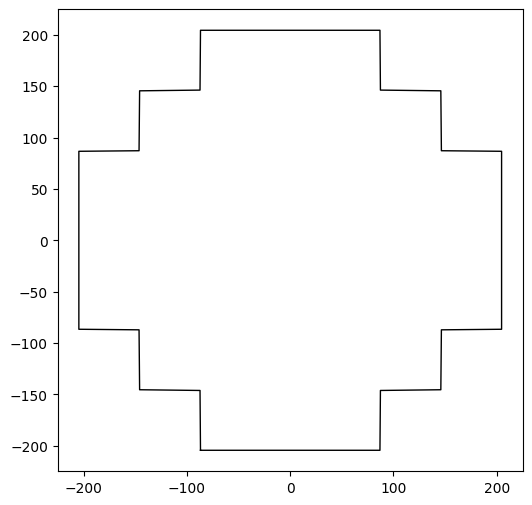

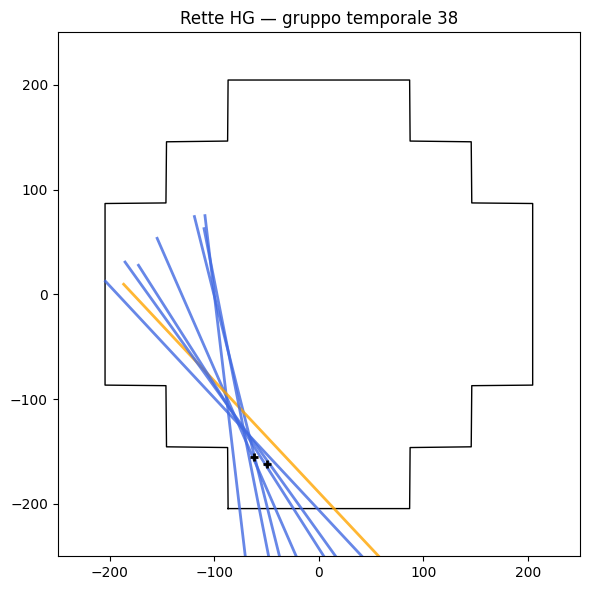

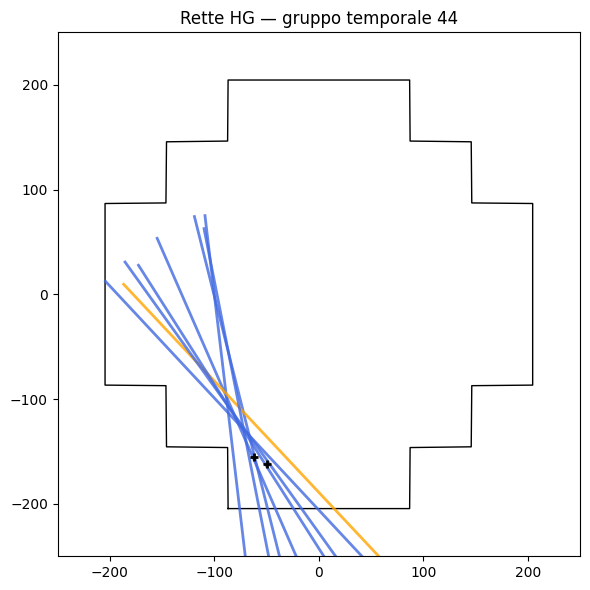

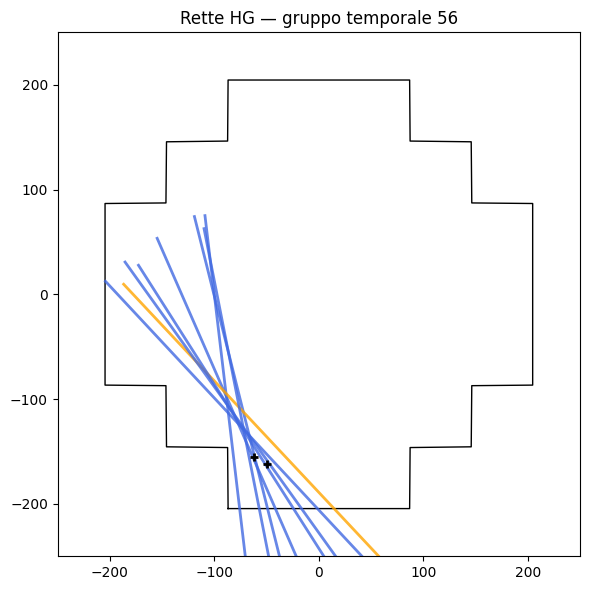

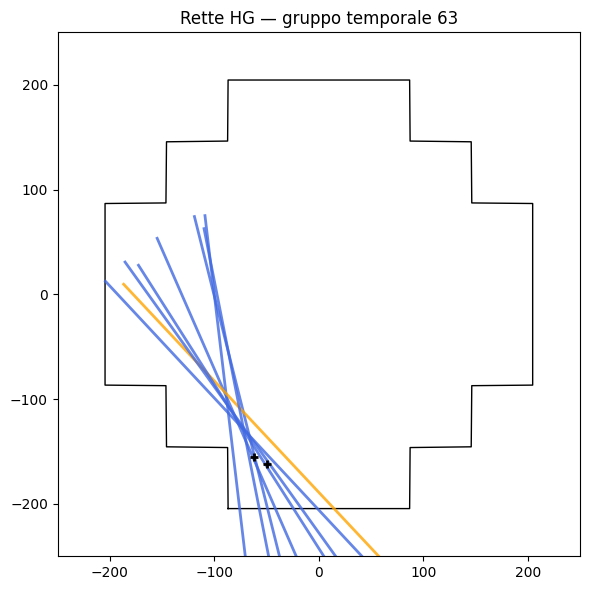

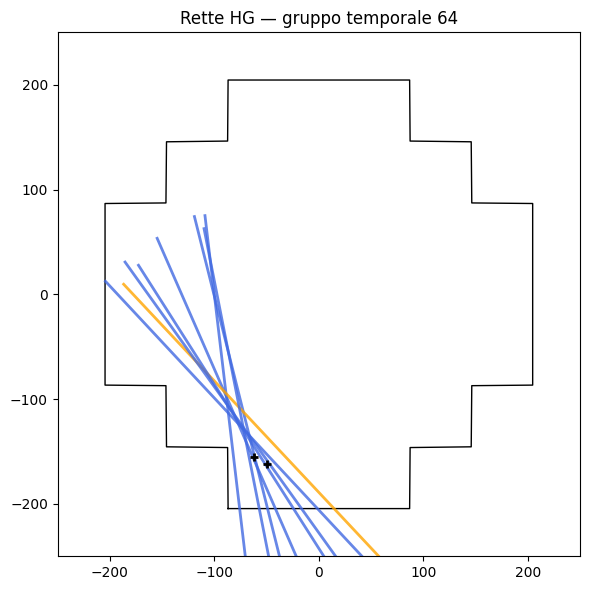

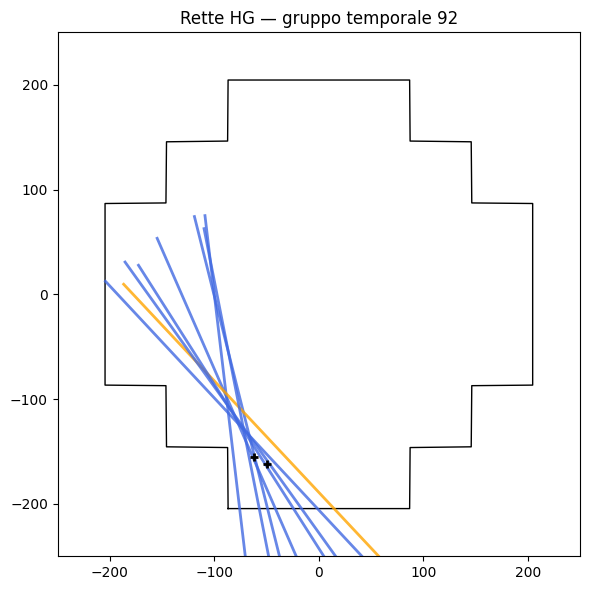

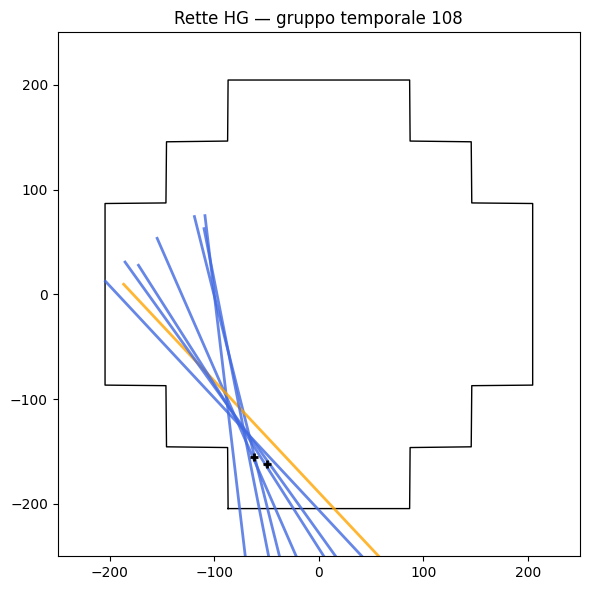

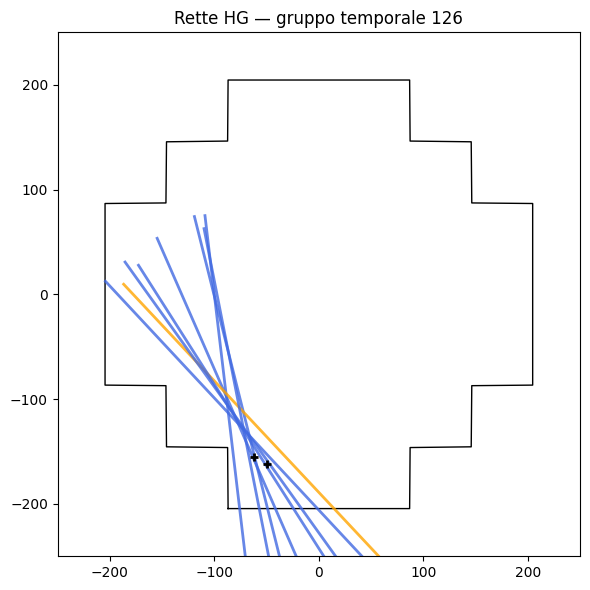

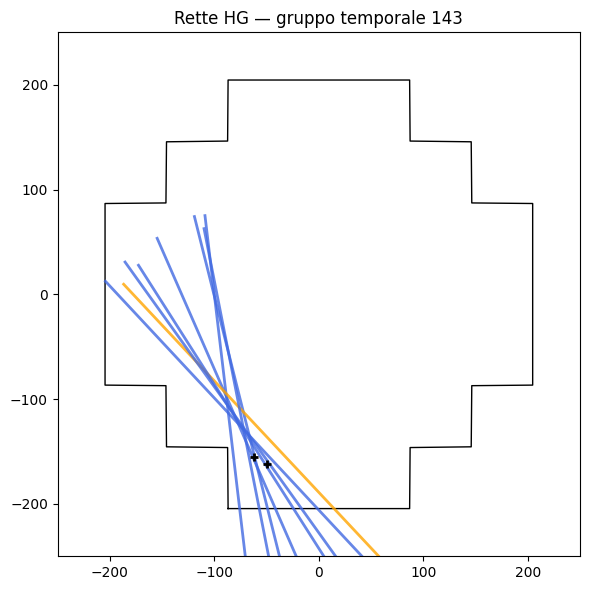

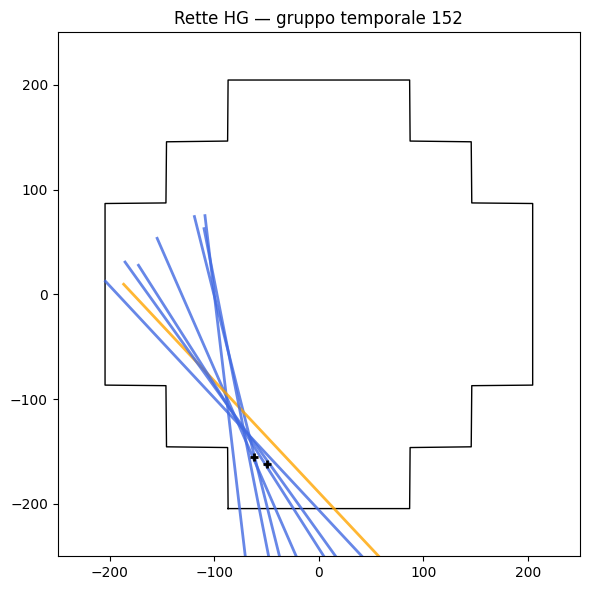

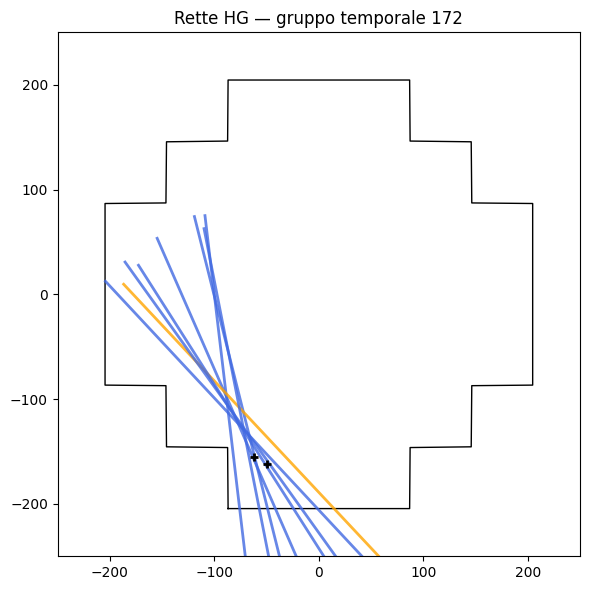

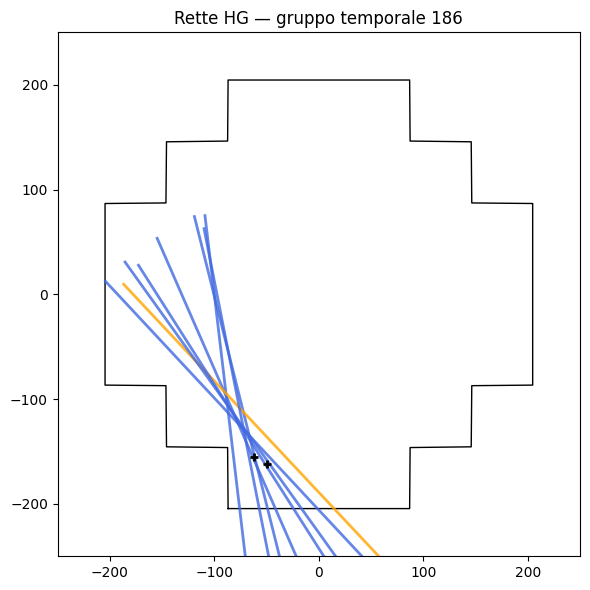

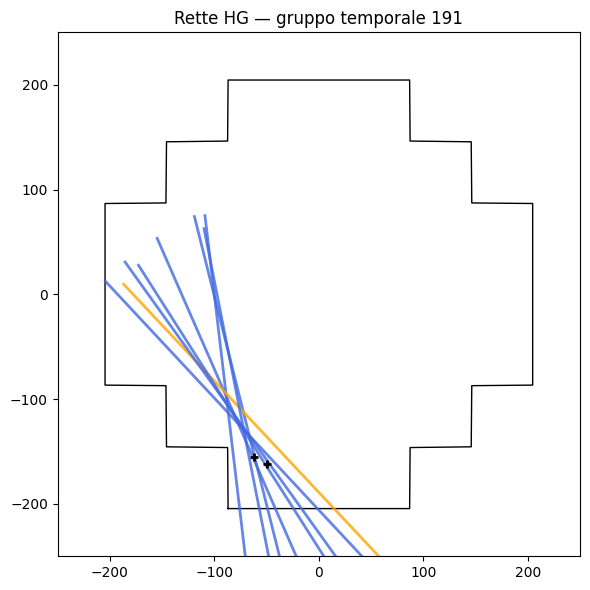

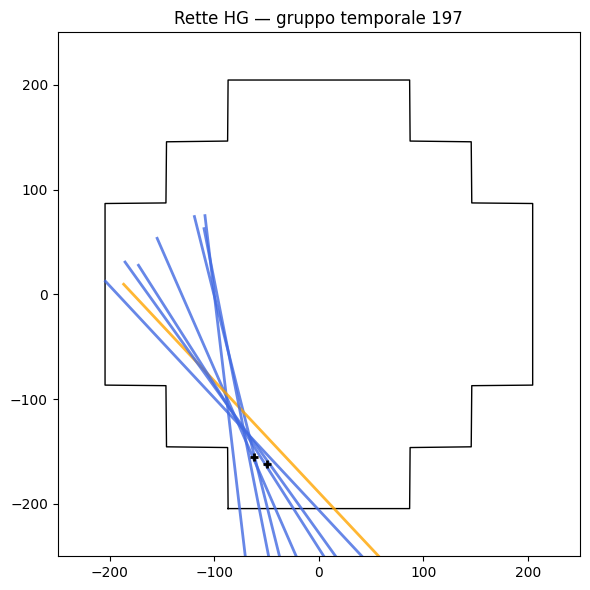

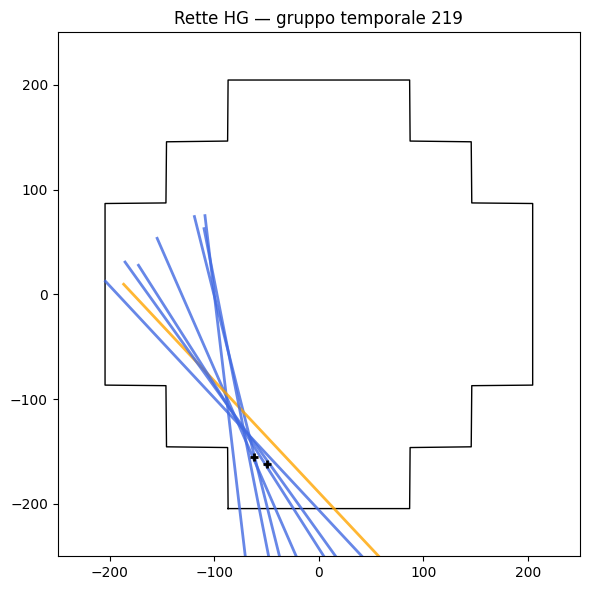

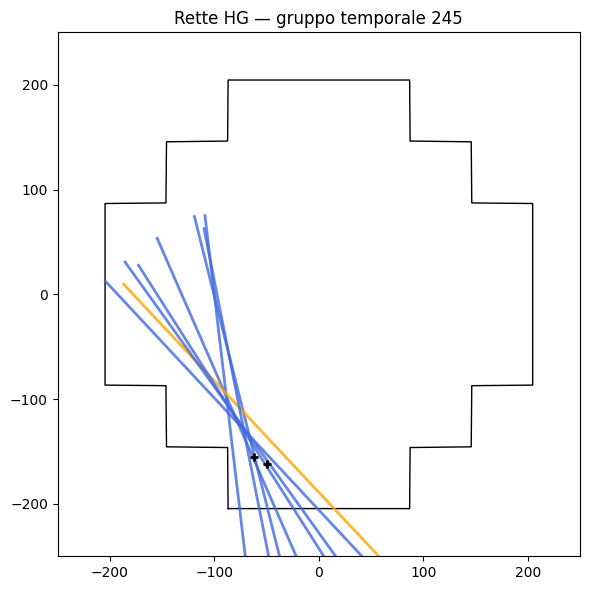

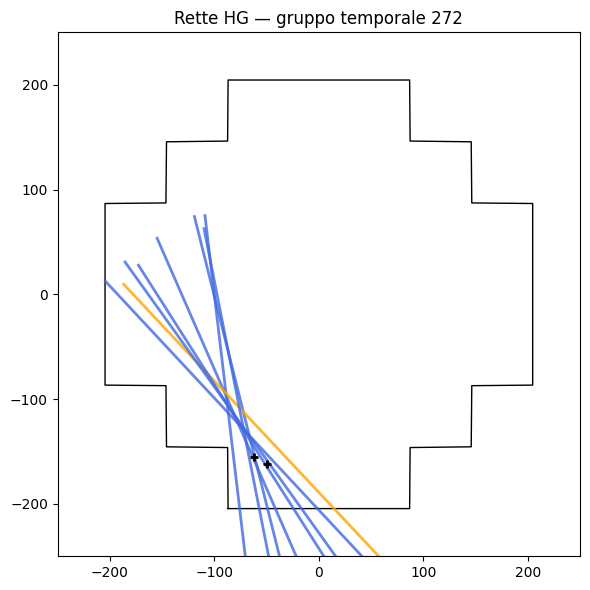

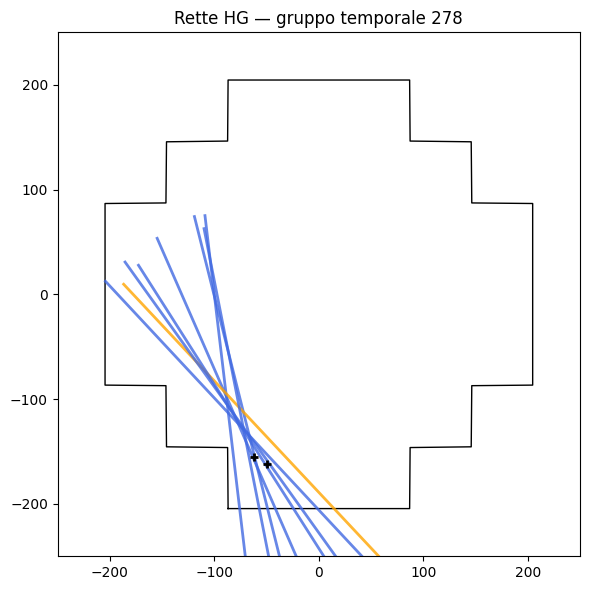

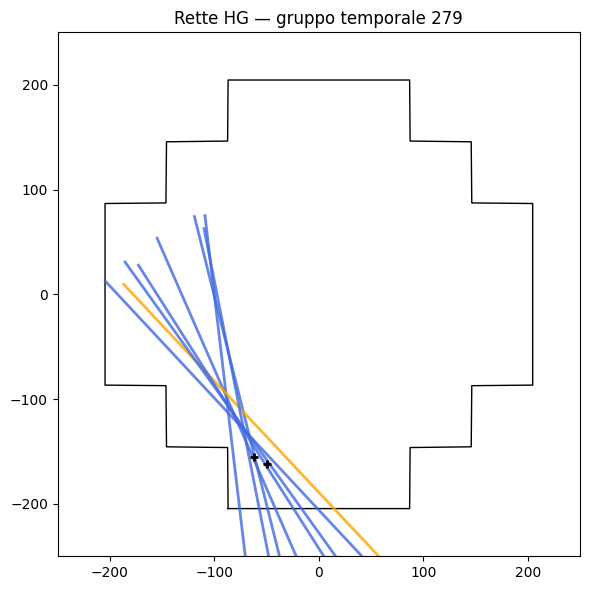

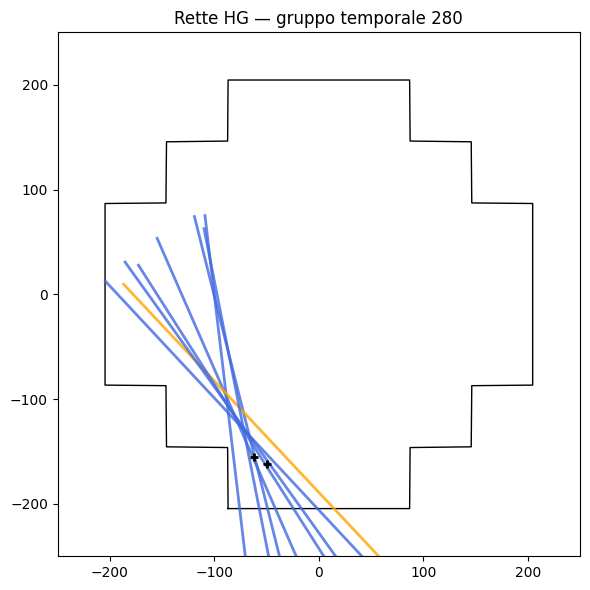

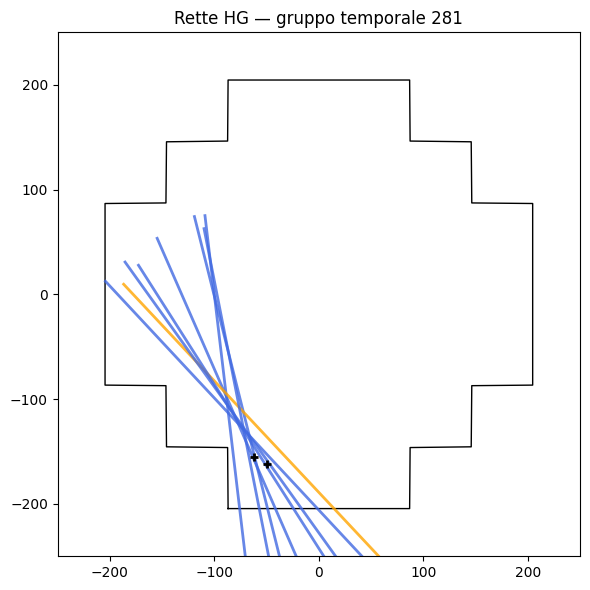

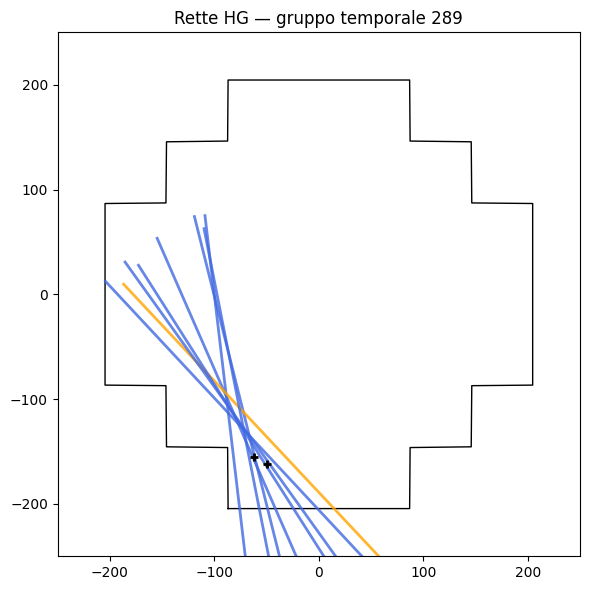

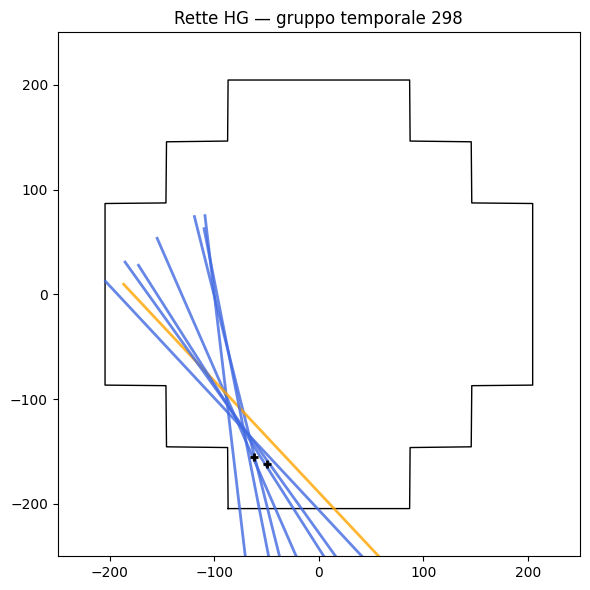

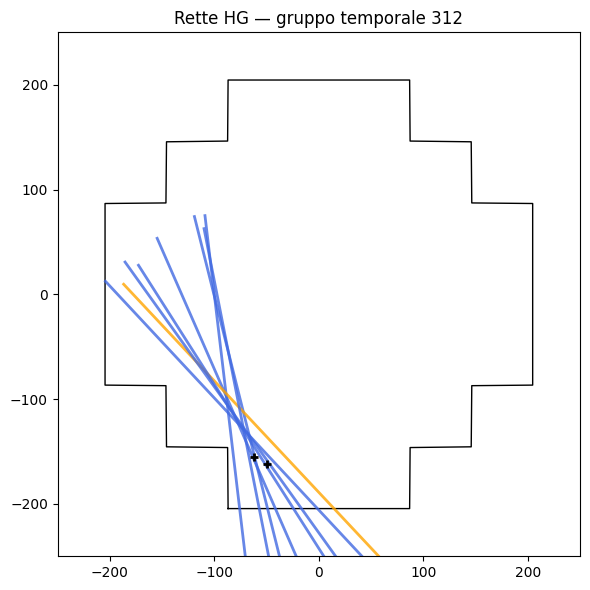

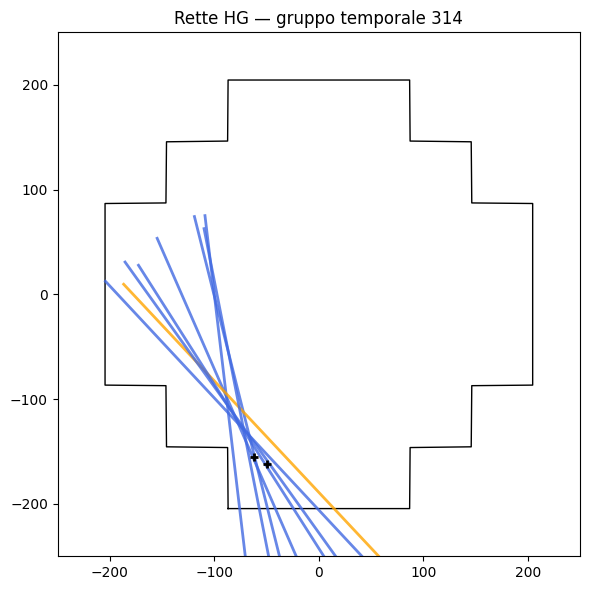

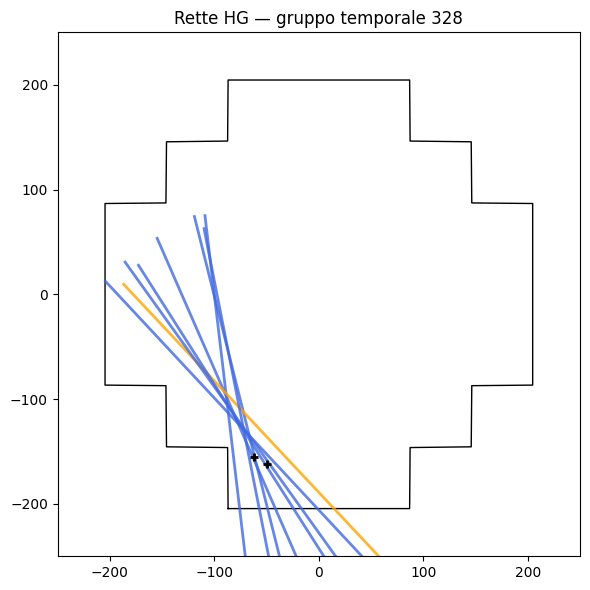

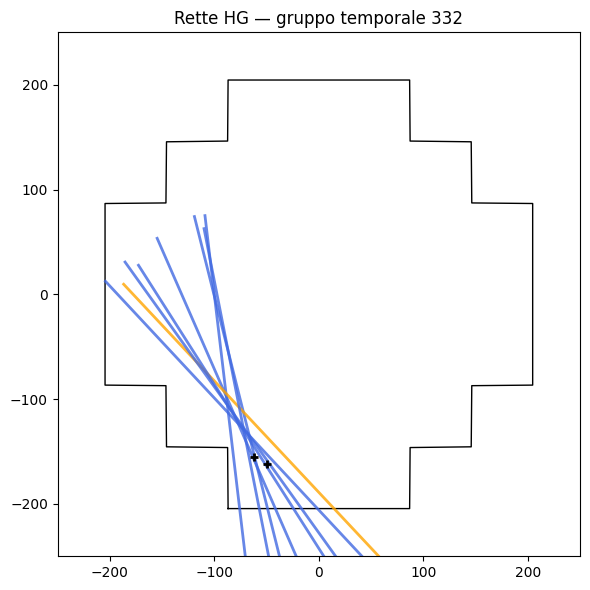

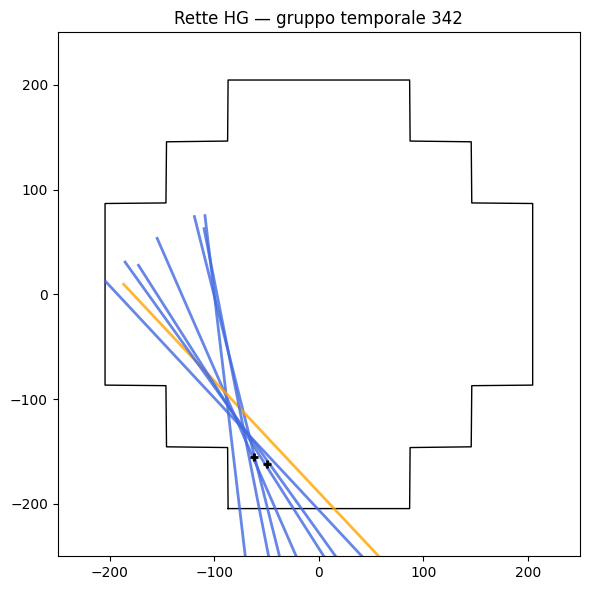

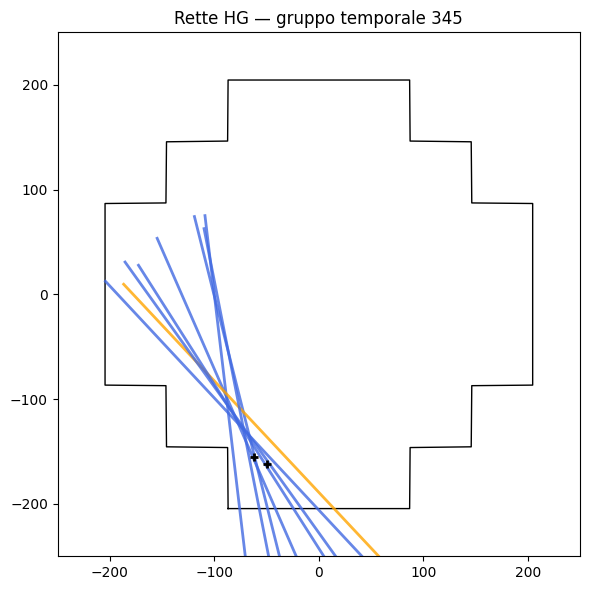

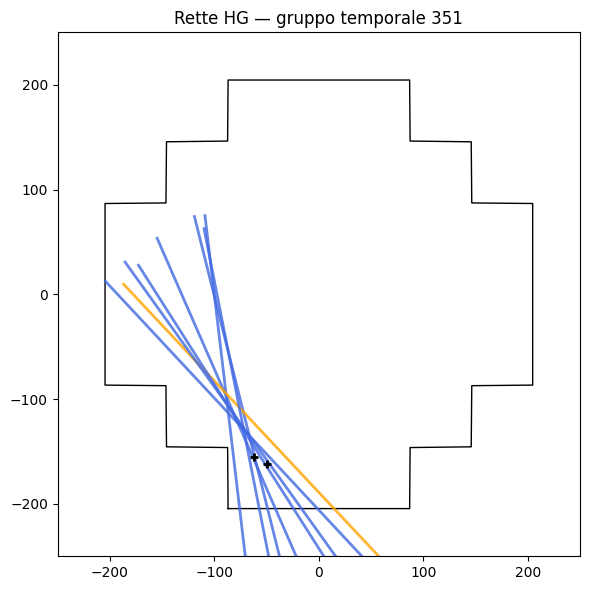

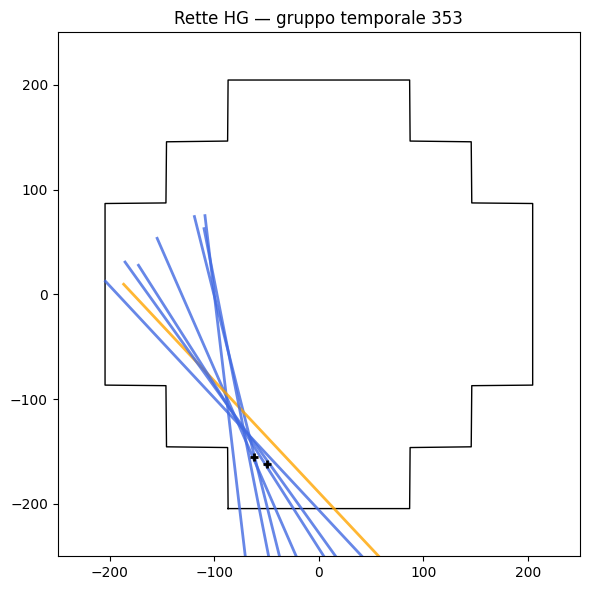

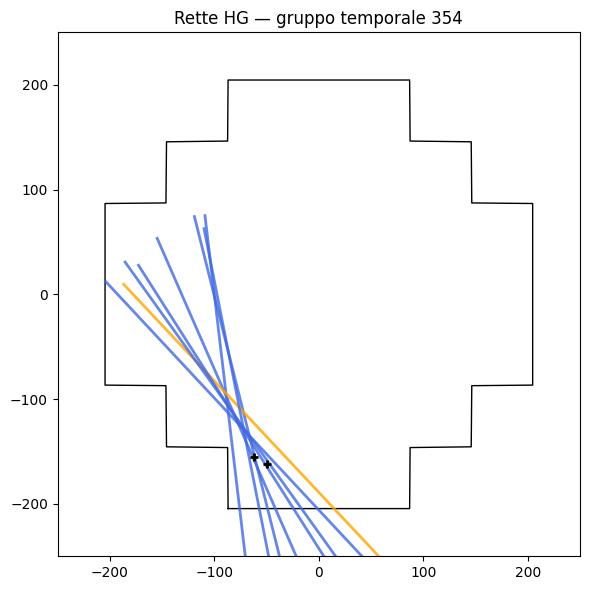

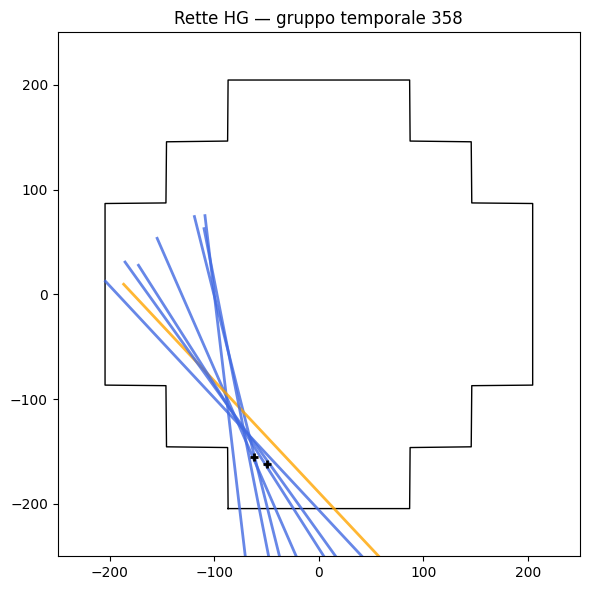

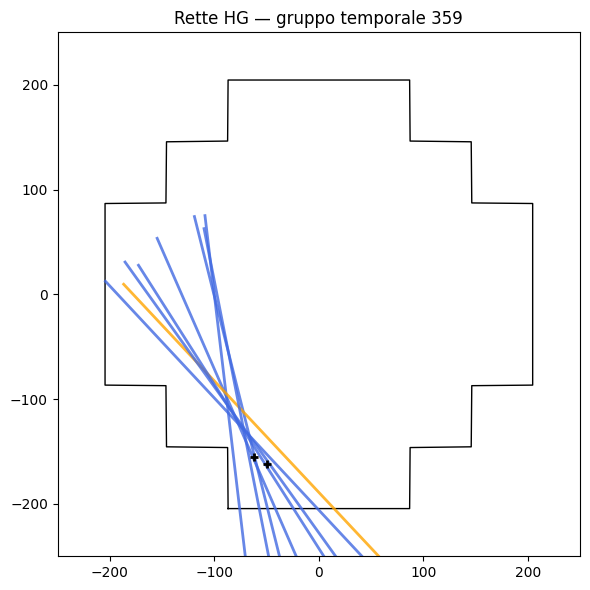

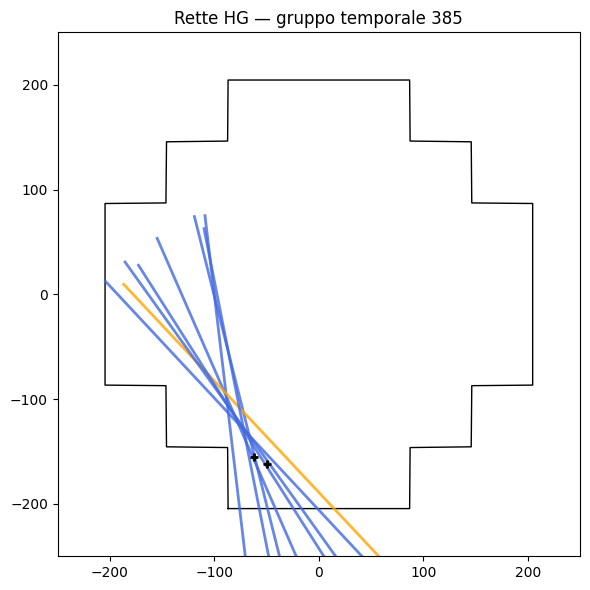

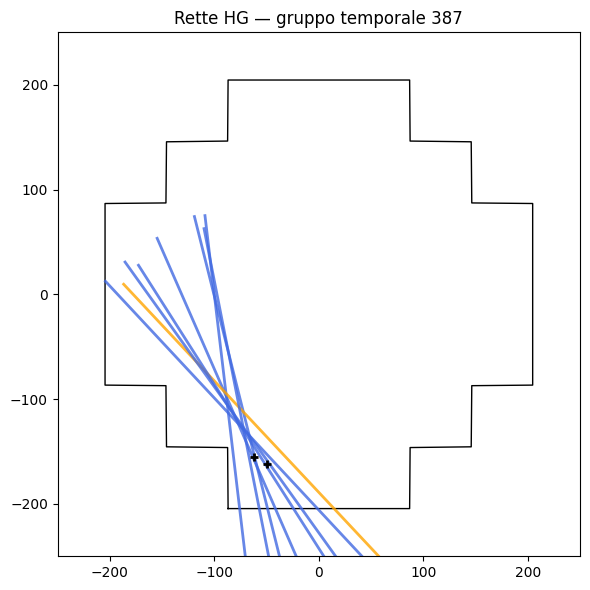

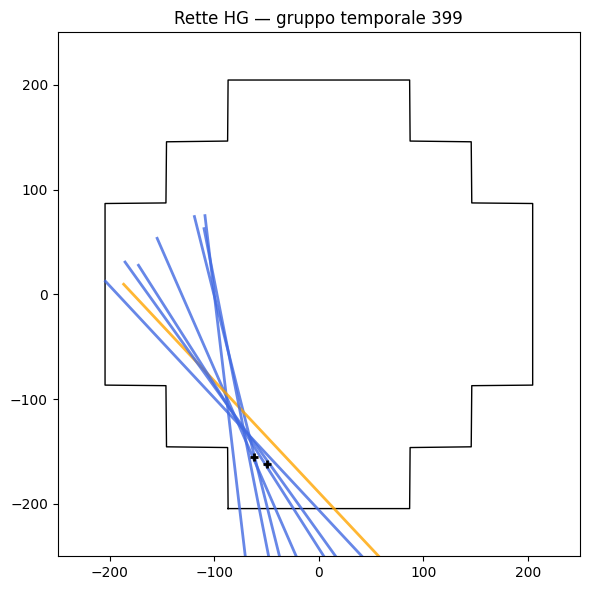

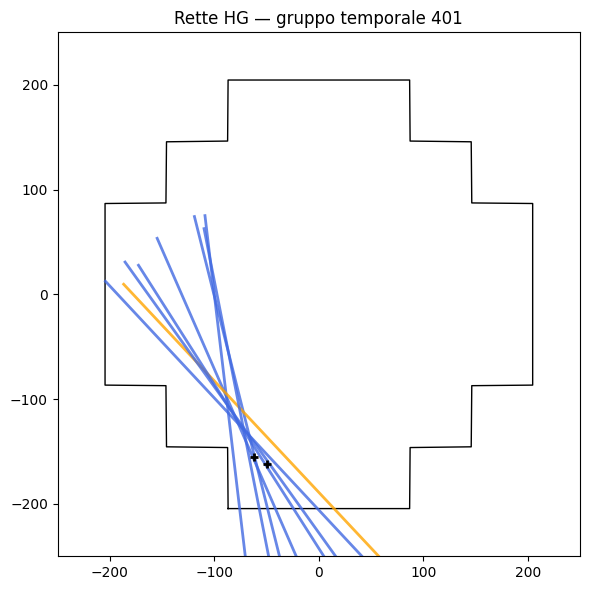

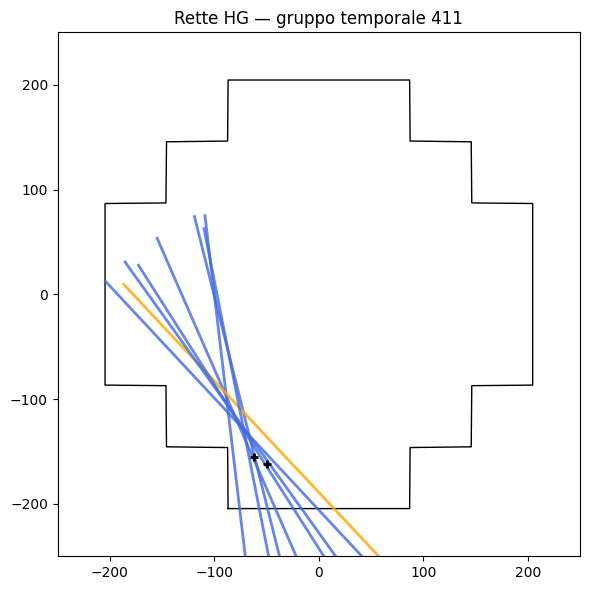

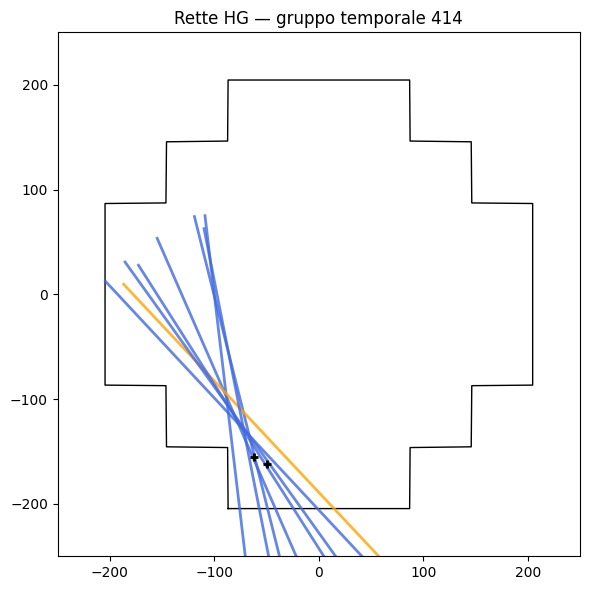

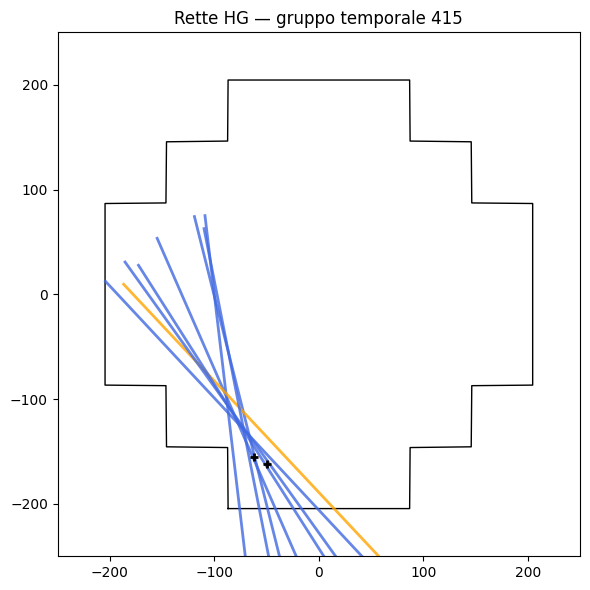

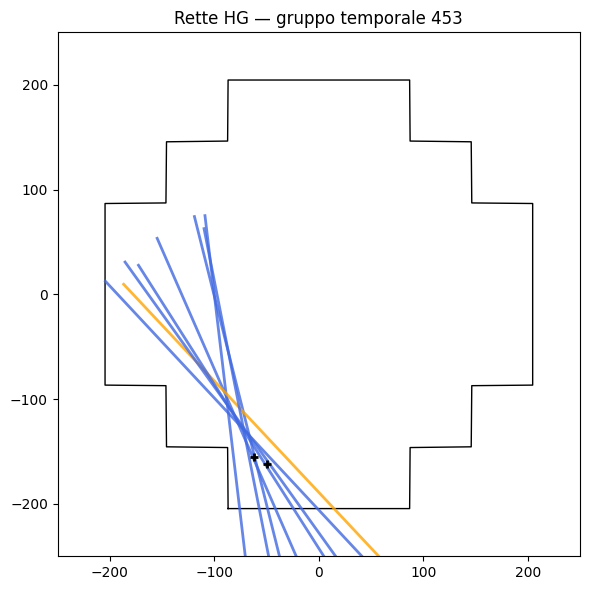

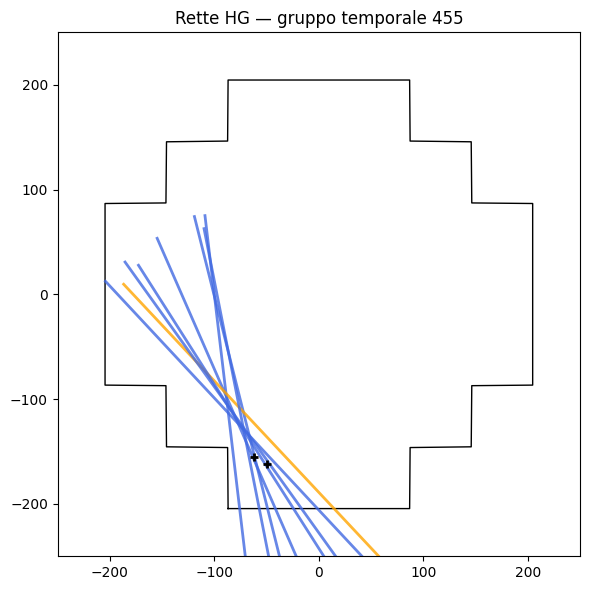

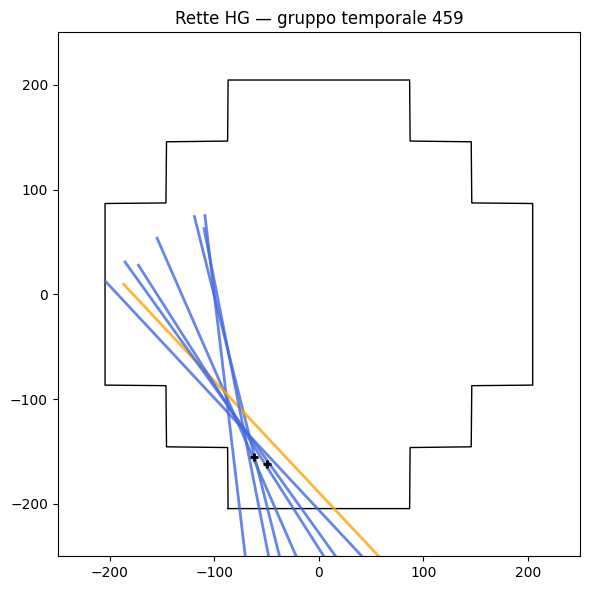

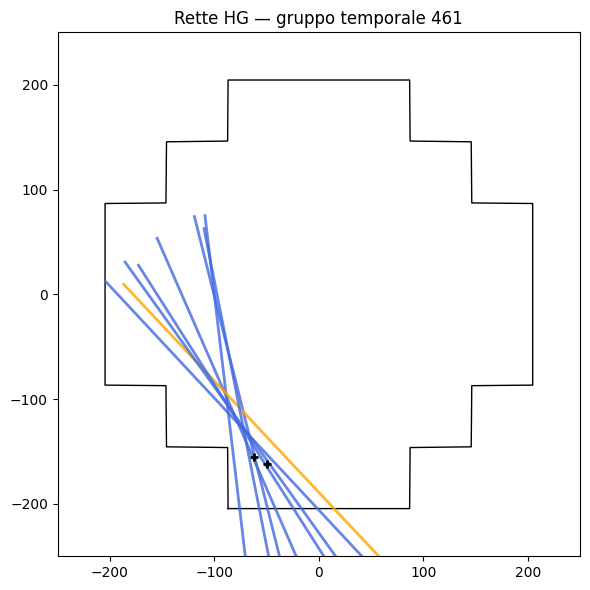

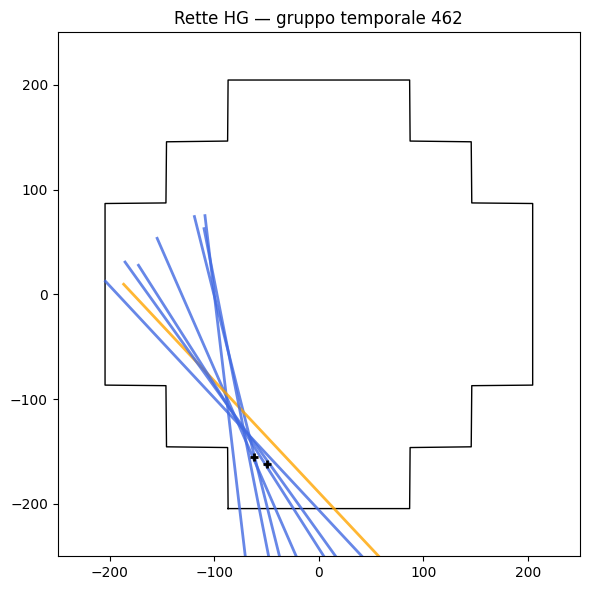

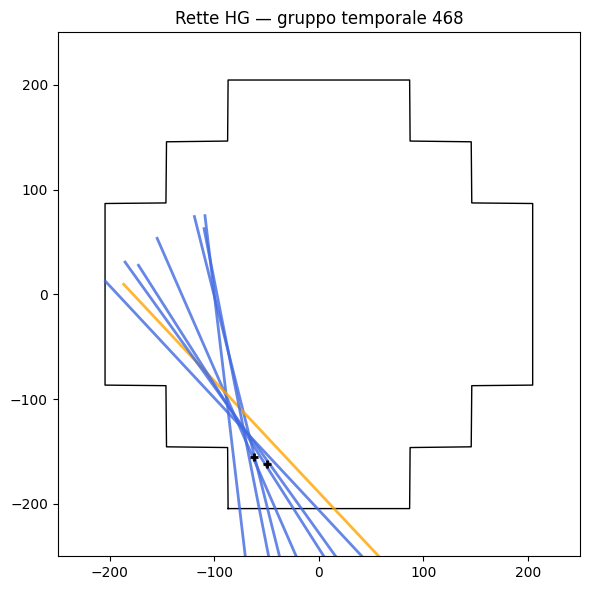

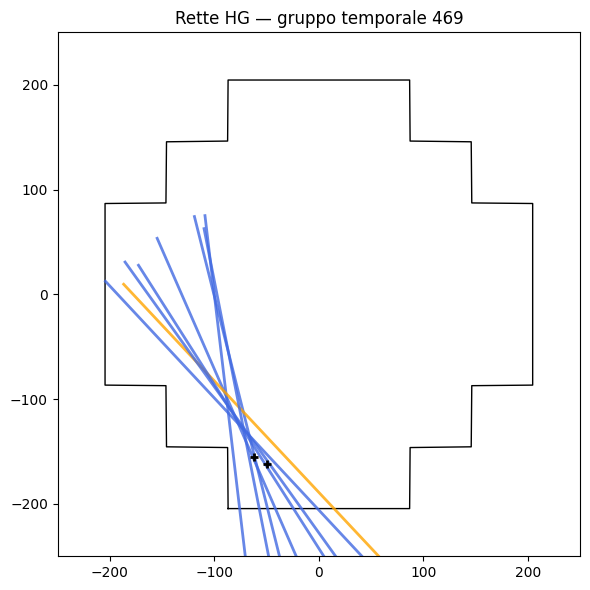

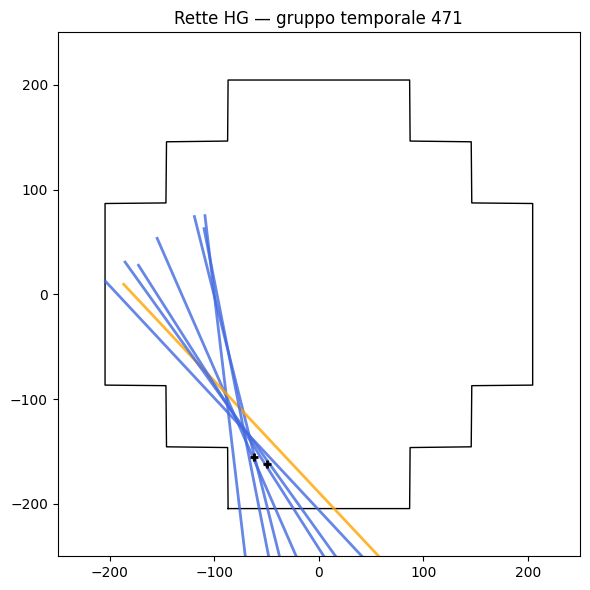

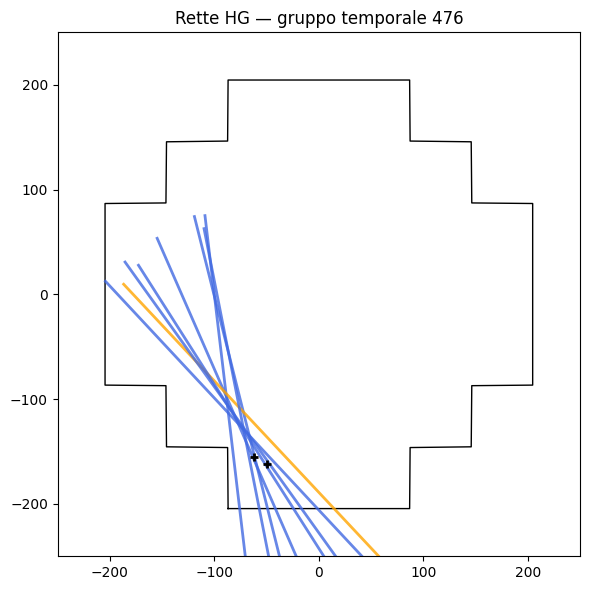

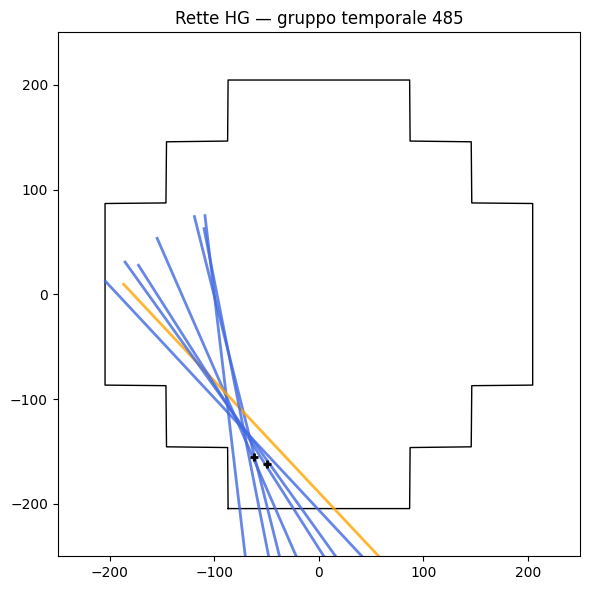

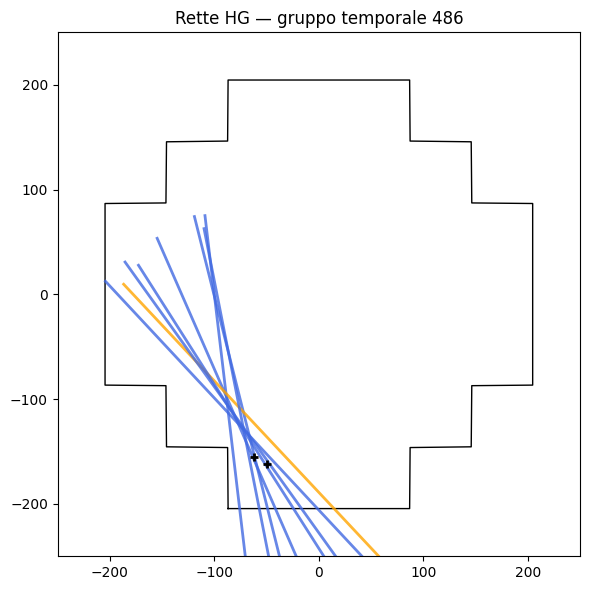

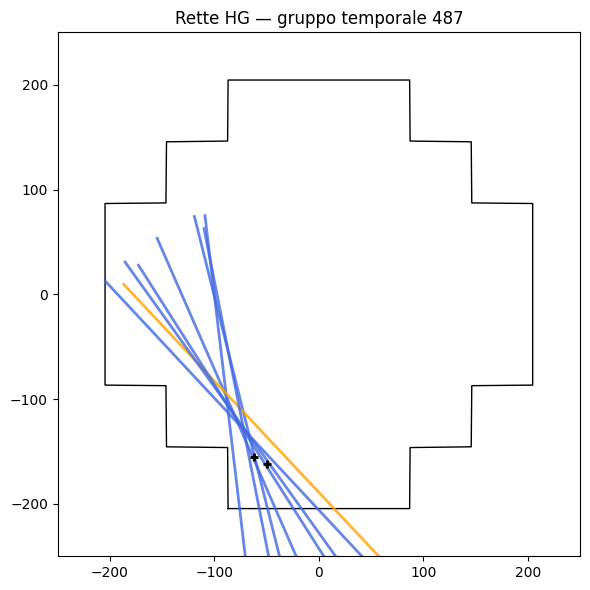

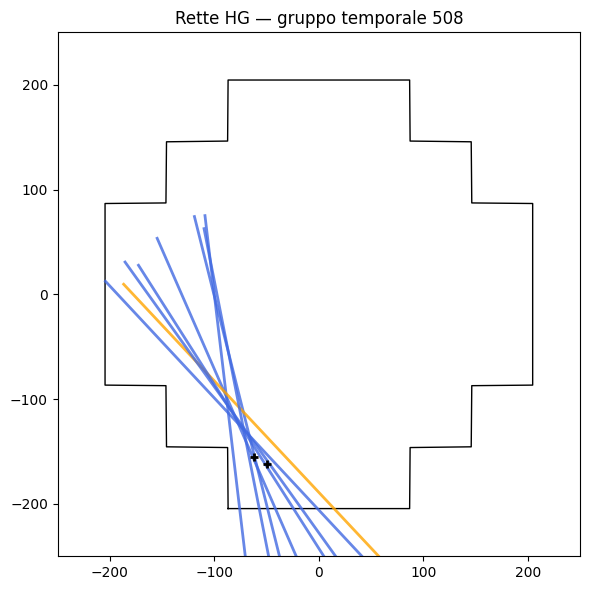

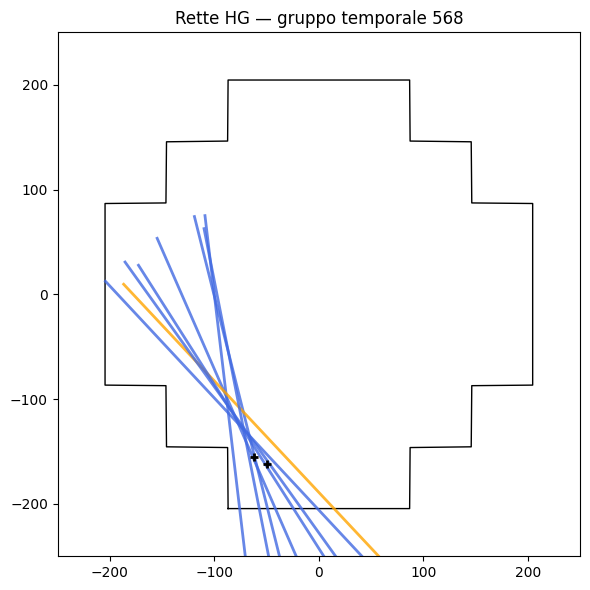

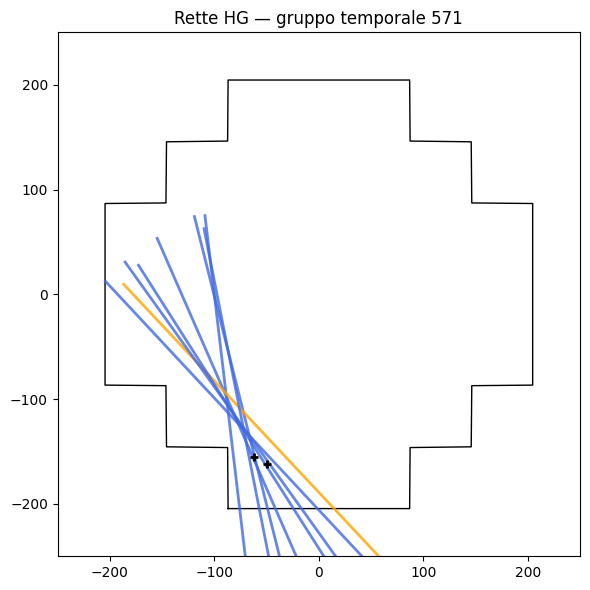

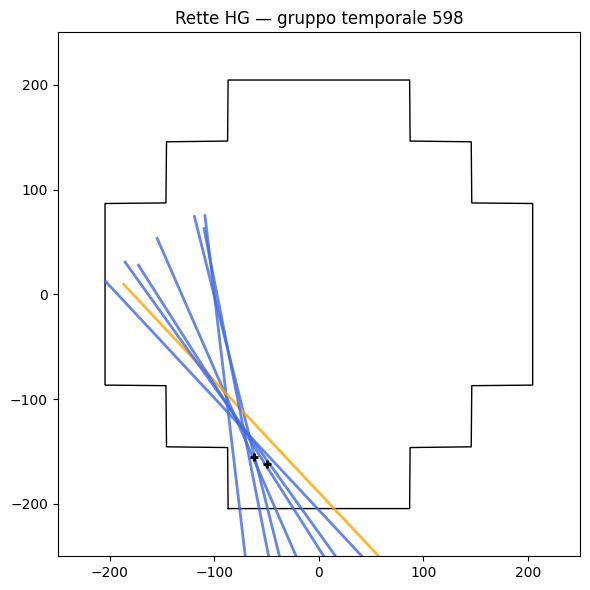

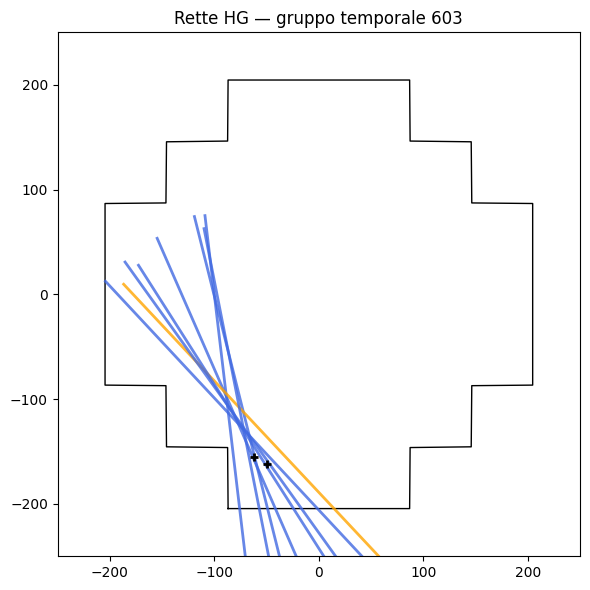

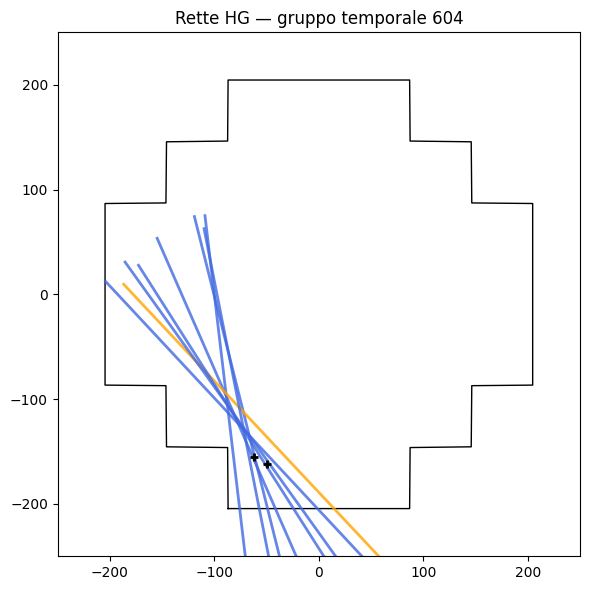

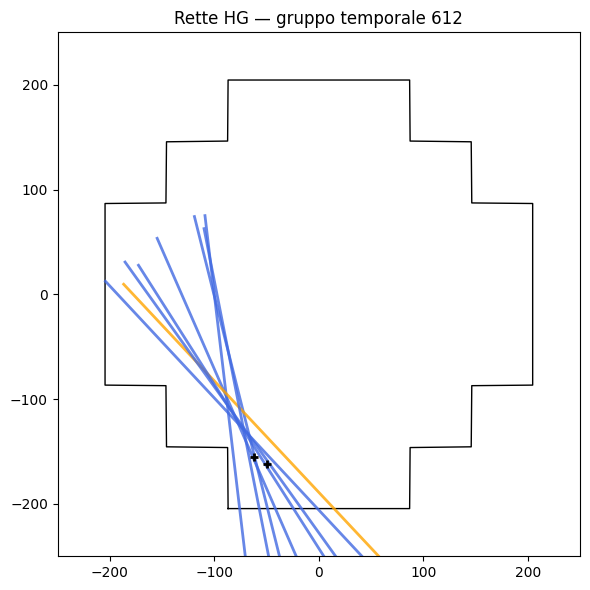

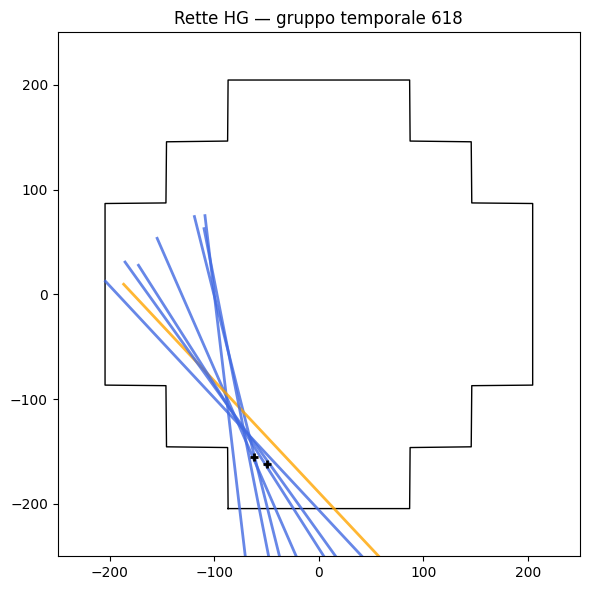

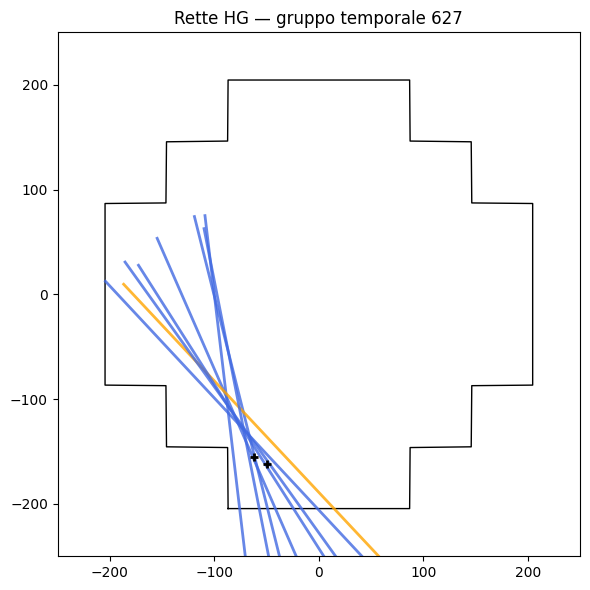

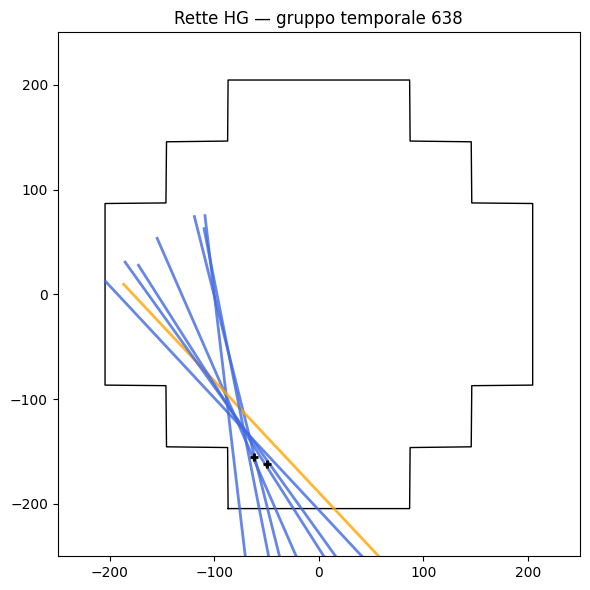

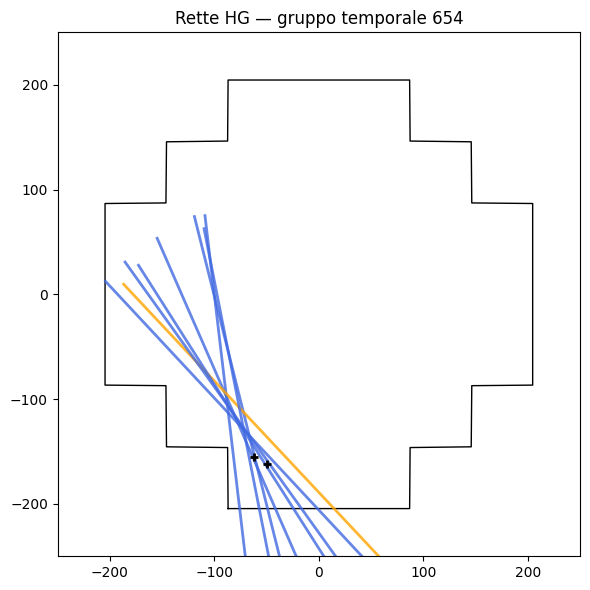

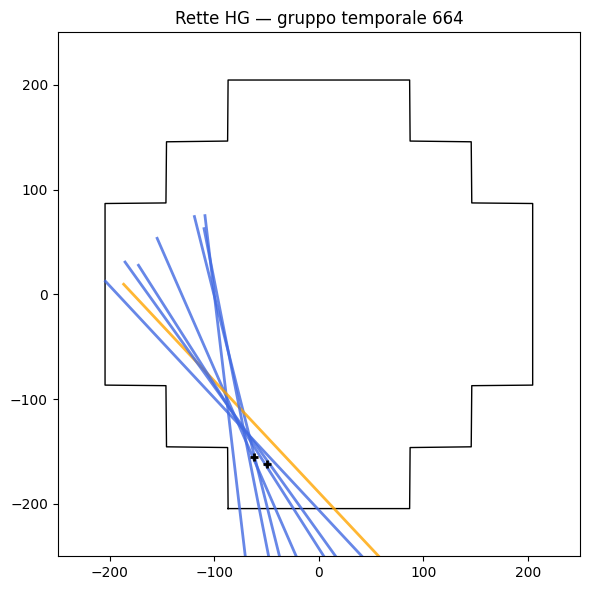

KeyboardInterrupt: 

In [ ]:
colori = {-1: "red", 0: "royalblue", 1: "orange"}  # colori per eventi

for gid in good_groups:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(xfp, yfp, 'k-', linewidth=1)
    for r in rette_hg:
        p0 = r["p0"]
        d  = r["d"]
        col = colori[r["event"]]

        x1 = p0[0] - L * d[0]
        y1 = p0[1] - L * d[1]
        x2 = p0[0] + L * d[0]
        y2 = p0[1] + L * d[1]
        ax.plot([x1, x2], [y1, y2],color=col, linewidth=2, alpha=0.8)

    # centri degli eventi
    ax.scatter(centro0[0], centro0[1],
               marker='+', c='black', linewidths=2, zorder=3, label="Centro evento 0")

    ax.scatter(centro1[0], centro1[1],
               marker='+', c='black', linewidths=2, zorder=3, label="Centro evento 1")

    ax.set_title(f"Rette HG — gruppo temporale {gid}")
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)

    plt.tight_layout()
    plt.show()
